In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
from pathlib import Path

# NHANES 2021–2023: descarga y preparación de datos

BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles"

FILES = {
    "demo": f"{BASE}/DEMO_L.XPT",
    "bmx":  f"{BASE}/BMX_L.XPT",
    "bpq":  f"{BASE}/BPQ_L.XPT",
    "bpxo": f"{BASE}/BPXO_L.XPT",
    "smq":  f"{BASE}/SMQ_L.XPT",
    "alq":  f"{BASE}/ALQ_L.XPT",
    "paq":  f"{BASE}/PAQ_L.XPT",
    "dpq":  f"{BASE}/DPQ_L.XPT",
}

def read_nhanes_xpt(url):
    """Lectura de archivos XPT de NHANES."""
    
    response = requests.get(url, timeout=60)
    response.raise_for_status()

    return pd.read_sas(BytesIO(response.content), format="xport")


# Descarga de módulos

dfs = {name: read_nhanes_xpt(url) for name, url in FILES.items()}


# Comprobación de SEQN

missing_seqn = [k for k, d in dfs.items() if "SEQN" not in d.columns]

if missing_seqn:
    raise ValueError(f"Falta SEQN en: {missing_seqn}")


# Revisión de duplicados

for name, d in dfs.items():

    n_rows = d.shape[0]
    n_unique = d["SEQN"].nunique(dropna=True)

    if n_rows != n_unique:
        print(f"Aviso: {name} contiene SEQN duplicados.")
    else:
        print(f"{name}: OK")


# Merge de tablas

df = dfs["demo"].copy()

for key in ["bmx", "bpq", "bpxo", "smq", "alq", "paq", "dpq"]:
    df = df.merge(dfs[key], on="SEQN", how="left")

print("\nDimensiones tras merge:", df.shape)


# Guardado del dataset completo

out_path = Path.home() / "Desktop" / "TFG" / "NHANES_2021_2023_merged.csv"

out_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(out_path, index=False)

print("CSV guardado en:", out_path)


# Filtrado: mujeres mayores de edad

gender_map = {
    1: "Male",
    2: "Female"
}

df["Gender"] = df["RIAGENDR"].map(gender_map)

df["Age"] = pd.to_numeric(df["RIDAGEYR"], errors="coerce")

df_target = df.loc[
    (df["RIAGENDR"] == 2) &
    (df["Age"] >= 18)
].copy()


# Resumen de edad

summary = {
    "n": int(df_target.shape[0]),
    "edad_min": float(df_target["Age"].min(skipna=True)),
    "edad_max": float(df_target["Age"].max(skipna=True)),
}

print("\nResumen muestra final:")
print(summary)

print("Dimensiones df_target:", df_target.shape)


# Variables resumen de presión arterial

sbp_cols = ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
dbp_cols = ["BPXODI1", "BPXODI2", "BPXODI3"]
pls_cols = ["BPXOPLS1", "BPXOPLS2", "BPXOPLS3"]

cols_bp_all = [
    c for c in (sbp_cols + dbp_cols + pls_cols)
    if c in df_target.columns
]

df_target[cols_bp_all] = df_target[cols_bp_all].apply(
    pd.to_numeric,
    errors="coerce"
)

df_target["SBP_mean"] = df_target[sbp_cols].mean(axis=1, skipna=True)

df_target["DBP_mean"] = df_target[dbp_cols].mean(axis=1, skipna=True)

df_target["Pulse_mean"] = df_target[pls_cols].mean(axis=1, skipna=True)


print("\nPrimeras filas de presión arterial:")

print(
    df_target[
        sbp_cols + ["SBP_mean"] +
        dbp_cols + ["DBP_mean"] +
        pls_cols + ["Pulse_mean"]
    ].head()
)


# Tamaños muestrales

n_total = int(df.shape[0])

n_mujeres = int((df["RIAGENDR"] == 2).sum())

n_final = int(df_target.shape[0])

print("\nn_total:", n_total)
print("n_mujeres:", n_mujeres)
print("n_final:", n_final)


# Comprobación de IDs únicos

n_ids_unicos = int(df_target["SEQN"].nunique(dropna=True))

n_filas = int(df_target.shape[0])

print("\nSEQN únicos:", n_ids_unicos)
print("Filas totales:", n_filas)


# Tabla resumen de tamaños

tabla_tamanos = pd.DataFrame({
    "Fase": [
        "Muestra inicial NHANES 2021–2023",
        "Mujeres identificadas",
        "Mujeres mayores de 18 años",
        "SEQN únicos"
    ],
    "n": [
        n_total,
        n_mujeres,
        n_final,
        n_ids_unicos
    ]
})

print("\nTabla de tamaños:")
print(tabla_tamanos)


# Guardado de tablas y muestra final

tabla_path = out_path.parent / "tabla_tamanos.csv"

tabla_tamanos.to_csv(tabla_path, index=False)

print("Tabla guardada en:", tabla_path)


out_target_path = (
    Path.home() /
    "Desktop" /
    "TFG" /
    "NHANES_2021_2023_female_18plus.csv"
)

df_target.to_csv(out_target_path, index=False)

print("CSV final guardado en:", out_target_path)

demo: OK
bmx: OK
bpq: OK
bpxo: OK
smq: OK
alq: OK
paq: OK
dpq: OK

Dimensiones tras merge: (11933, 97)
CSV guardado en: C:\Users\carme\Desktop\TFG\NHANES_2021_2023_merged.csv

Resumen muestra final:
{'n': 4496, 'edad_min': 18.0, 'edad_max': 80.0}
Dimensiones df_target: (4496, 99)

Primeras filas de presión arterial:
    BPXOSY1  BPXOSY2  BPXOSY3    SBP_mean  BPXODI1  BPXODI2  BPXODI3  \
2     111.0    112.0    104.0  109.000000     79.0     80.0     76.0   
7       NaN      NaN      NaN         NaN      NaN      NaN      NaN   
9     143.0    136.0    145.0  141.333333     76.0     74.0     78.0   
10    130.0    128.0    129.0  129.000000     95.0    100.0    104.0   
12    113.0    106.0    115.0  111.333333     78.0     78.0     68.0   

     DBP_mean  BPXOPLS1  BPXOPLS2  BPXOPLS3  Pulse_mean  
2   78.333333      84.0      83.0      77.0   81.333333  
7         NaN       NaN       NaN       NaN         NaN  
9   76.000000      80.0      80.0      77.0   79.000000  
10  99.666667    

# BLOQUES DE VARIALES


 ## CÓDIGO PARA SELECCIONAR LAS VARIABLES

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Creación del dataset EDA

print("""
--------------------------------------------
Creación del dataset para análisis EDA
--------------------------------------------
""")

# Variables resumen de presión arterial

sbp_cols = ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
dbp_cols = ["BPXODI1", "BPXODI2", "BPXODI3"]
pls_cols = ["BPXOPLS1", "BPXOPLS2", "BPXOPLS3"]

cols_bp_all = [
    c for c in (sbp_cols + dbp_cols + pls_cols)
    if c in df_target.columns
]

df_target[cols_bp_all] = df_target[cols_bp_all].apply(
    pd.to_numeric,
    errors="coerce"
)

df_target["SBP_mean"] = df_target[sbp_cols].mean(axis=1, skipna=True)

df_target["DBP_mean"] = df_target[dbp_cols].mean(axis=1, skipna=True)

df_target["Pulse_mean"] = df_target[pls_cols].mean(axis=1, skipna=True)


# PHQ-9 total

dpq_cols = [
    c for c in df_target.columns
    if c.startswith("DPQ") and len(c) == 6
]

dpq_cols = sorted(dpq_cols)

df_target[dpq_cols] = df_target[dpq_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

df_target["PHQ9_total"] = df_target[dpq_cols].sum(
    axis=1,
    skipna=False
)

n_phq_missing = int(df_target["PHQ9_total"].isna().sum())

print("\nMissing en PHQ9_total:", n_phq_missing)


# Variables seleccionadas

variables = {

    # Sociodemográficas
    "RIDAGEYR": "Edad",
    "DMDEDUC2": "Nivel educativo",
    "INDFMPIR": "Ratio ingreso familiar",

    # Antropometría
    "BMXBMI": "Índice de masa corporal",
    "BMXWAIST": "Circunferencia de cintura",

    # Clínica
    "SBP_mean": "Presión arterial sistólica media",
    "DBP_mean": "Presión arterial diastólica media",
    "Pulse_mean": "Frecuencia cardiaca media",

    # Estilo de vida
    "SMQ020": "Fuma actualmente",
    "ALQ111": "Consumo de alcohol",
    "PAQ650": "Actividad física vigorosa",
    "PHQ9_total": "PHQ-9 total"
}


# Selección de variables disponibles

present = [
    c for c in variables.keys()
    if c in df_target.columns
]

missing = [
    c for c in variables.keys()
    if c not in df_target.columns
]

print("\nVariables presentes:")
print(present)

print("\nVariables ausentes:")
print(missing)


# Dataset EDA

df_eda = df_target[present].copy()

print("\nDimensiones iniciales:", df_eda.shape)


# Limpieza de códigos especiales NHANES

df_eda.replace(
    [7, 9, 77, 99, 777, 999],
    np.nan,
    inplace=True
)


# Eliminación de missing en PHQ9_total

before = df_eda.shape[0]

if "PHQ9_total" in df_eda.columns:
    df_eda = df_eda.dropna(subset=["PHQ9_total"])

after = df_eda.shape[0]

print("\nFilas antes:", before)
print("Filas después:", after)
print("Eliminadas:", before - after)


# Tipo de variables

tipos = {
    "RIDAGEYR": "Numérica continua",
    "DMDEDUC2": "Ordinal",
    "INDFMPIR": "Numérica continua",
    "BMXBMI": "Numérica continua",
    "BMXWAIST": "Numérica continua",
    "SBP_mean": "Numérica continua",
    "DBP_mean": "Numérica continua",
    "Pulse_mean": "Numérica continua",
    "SMQ020": "Binaria",
    "ALQ111": "Binaria",
    "PAQ650": "Binaria",
    "PHQ9_total": "Numérica discreta"
}


# Diccionario final

diccionario_final = pd.DataFrame({
    "Variable": present,
    "Descripción": [variables[v] for v in present],
    "Tipo": [tipos.get(v, "No especificado") for v in present]
})

print("\nDiccionario de variables:")
print(diccionario_final)


# Guardado de archivos

out_dir = Path.home() / "Desktop" / "TFG"

out_dir.mkdir(parents=True, exist_ok=True)

df_eda_path = out_dir / "NHANES_2021_2023_female_18plus_EDA.csv"

dicc_path = out_dir / "diccionario_variables_TFG.csv"

df_eda.to_csv(df_eda_path, index=False)

diccionario_final.to_csv(dicc_path, index=False)

print("\nArchivos guardados correctamente.")


--------------------------------------------
Creación del dataset para análisis EDA
--------------------------------------------


Missing en PHQ9_total: 2076

Variables presentes:
['RIDAGEYR', 'DMDEDUC2', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'SBP_mean', 'DBP_mean', 'Pulse_mean', 'SMQ020', 'ALQ111', 'PHQ9_total']

Variables ausentes:
['PAQ650']

Dimensiones iniciales: (4496, 11)

Filas antes: 4496
Filas después: 2188
Eliminadas: 2308

Diccionario de variables:
      Variable                        Descripción               Tipo
0     RIDAGEYR                               Edad  Numérica continua
1     DMDEDUC2                    Nivel educativo            Ordinal
2     INDFMPIR             Ratio ingreso familiar  Numérica continua
3       BMXBMI            Índice de masa corporal  Numérica continua
4     BMXWAIST          Circunferencia de cintura  Numérica continua
5     SBP_mean   Presión arterial sistólica media  Numérica continua
6     DBP_mean  Presión arterial diastólica media  Num

# EDA 


In [3]:
print(df_eda.dtypes)

for col in df_eda.columns:
    print(col, "-> valores únicos:", df_eda[col].nunique())

RIDAGEYR      float64
DMDEDUC2      float64
INDFMPIR      float64
BMXBMI        float64
BMXWAIST      float64
SBP_mean      float64
DBP_mean      float64
Pulse_mean    float64
SMQ020        float64
ALQ111        float64
PHQ9_total    float64
dtype: object
RIDAGEYR -> valores únicos: 62
DMDEDUC2 -> valores únicos: 5
INDFMPIR -> valores únicos: 393
BMXBMI -> valores únicos: 357
BMXWAIST -> valores únicos: 675
SBP_mean -> valores únicos: 267
DBP_mean -> valores únicos: 179
Pulse_mean -> valores únicos: 192
SMQ020 -> valores únicos: 2
ALQ111 -> valores únicos: 2
PHQ9_total -> valores únicos: 30


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# Creación del dataset EDA

print("""
--------------------------------------------
Preparación del dataset EDA
--------------------------------------------
""")


# Variables resumen de presión arterial

sbp_cols = ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
dbp_cols = ["BPXODI1", "BPXODI2", "BPXODI3"]
pls_cols = ["BPXOPLS1", "BPXOPLS2", "BPXOPLS3"]

cols_bp_all = [
    c for c in (sbp_cols + dbp_cols + pls_cols)
    if c in df_target.columns
]

df_target[cols_bp_all] = df_target[cols_bp_all].apply(
    pd.to_numeric,
    errors="coerce"
)

df_target["SBP_mean"] = df_target[sbp_cols].mean(axis=1, skipna=True)

df_target["DBP_mean"] = df_target[dbp_cols].mean(axis=1, skipna=True)

df_target["Pulse_mean"] = df_target[pls_cols].mean(axis=1, skipna=True)


# Cálculo de PHQ-9 total

dpq_cols = [
    c for c in df_target.columns
    if c.startswith("DPQ") and len(c) == 6
]

dpq_cols = sorted(dpq_cols)

df_target[dpq_cols] = df_target[dpq_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

df_target["PHQ9_total"] = df_target[dpq_cols].sum(
    axis=1,
    skipna=False
)

n_phq_missing = int(df_target["PHQ9_total"].isna().sum())

print("\nMissing en PHQ9_total:", n_phq_missing)


# Variables seleccionadas para el análisis

variables = {

    # Sociodemográficas
    "RIDAGEYR": "Edad",
    "DMDEDUC2": "Nivel educativo",
    "INDFMPIR": "Ratio ingreso familiar",

    # Antropometría
    "BMXBMI": "Índice de masa corporal",
    "BMXWAIST": "Circunferencia de cintura",

    # Variables clínicas
    "SBP_mean": "Presión arterial sistólica media",
    "DBP_mean": "Presión arterial diastólica media",
    "Pulse_mean": "Frecuencia cardiaca media",

    # Estilo de vida
    "SMQ020": "Fuma actualmente",
    "ALQ111": "Consumo de alcohol",
    "PAQ650": "Actividad física vigorosa",
    "PHQ9_total": "PHQ-9 total"
}


# Variables disponibles

present = [
    c for c in variables.keys()
    if c in df_target.columns
]

missing = [
    c for c in variables.keys()
    if c not in df_target.columns
]

print("\nVariables presentes:")
print(present)

print("\nVariables ausentes:")
print(missing)


# Dataset EDA principal

df_eda_all = df_target[present].copy()

print("\nDimensiones iniciales:", df_eda_all.shape)


# Limpieza de códigos especiales NHANES

df_eda_all.replace(
    [7, 9, 77, 99, 777, 999],
    np.nan,
    inplace=True
)


# Subset completo en PHQ-9

if "PHQ9_total" in df_eda_all.columns:

    df_eda_phq = df_eda_all.dropna(
        subset=["PHQ9_total"]
    ).copy()

else:
    df_eda_phq = df_eda_all.copy()


print("\nFilas en df_eda_all:", df_eda_all.shape[0])

print("Filas en df_eda_phq:", df_eda_phq.shape[0])

print(
    "Filas excluidas por PHQ9 incompleto:",
    df_eda_all.shape[0] - df_eda_phq.shape[0]
)


# Diccionario de variables

tipos = {
    "RIDAGEYR": "Numérica continua",
    "DMDEDUC2": "Ordinal",
    "INDFMPIR": "Numérica continua",
    "BMXBMI": "Numérica continua",
    "BMXWAIST": "Numérica continua",
    "SBP_mean": "Numérica continua",
    "DBP_mean": "Numérica continua",
    "Pulse_mean": "Numérica continua",
    "SMQ020": "Binaria",
    "ALQ111": "Binaria",
    "PAQ650": "Binaria",
    "PHQ9_total": "Numérica discreta"
}

diccionario_final = pd.DataFrame({
    "Variable": present,
    "Descripción": [variables[v] for v in present],
    "Tipo": [tipos.get(v, "No especificado") for v in present]
})

print("\nDiccionario final:")
print(diccionario_final)


# Guardado de archivos

out_dir = Path.home() / "Desktop" / "TFG"

out_dir.mkdir(parents=True, exist_ok=True)

df_all_path = (
    out_dir /
    "NHANES_2021_2023_female_18plus_EDA_ALL.csv"
)

df_phq_path = (
    out_dir /
    "NHANES_2021_2023_female_18plus_EDA_PHQcomplete.csv"
)

dicc_path = (
    out_dir /
    "diccionario_variables_TFG.csv"
)

df_eda_all.to_csv(df_all_path, index=False)

df_eda_phq.to_csv(df_phq_path, index=False)

diccionario_final.to_csv(dicc_path, index=False)


print("\nArchivos guardados correctamente.")


--------------------------------------------
Preparación del dataset EDA
--------------------------------------------


Missing en PHQ9_total: 2076

Variables presentes:
['RIDAGEYR', 'DMDEDUC2', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'SBP_mean', 'DBP_mean', 'Pulse_mean', 'SMQ020', 'ALQ111', 'PHQ9_total']

Variables ausentes:
['PAQ650']

Dimensiones iniciales: (4496, 11)

Filas en df_eda_all: 4496
Filas en df_eda_phq: 2188
Filas excluidas por PHQ9 incompleto: 2308

Diccionario final:
      Variable                        Descripción               Tipo
0     RIDAGEYR                               Edad  Numérica continua
1     DMDEDUC2                    Nivel educativo            Ordinal
2     INDFMPIR             Ratio ingreso familiar  Numérica continua
3       BMXBMI            Índice de masa corporal  Numérica continua
4     BMXWAIST          Circunferencia de cintura  Numérica continua
5     SBP_mean   Presión arterial sistólica media  Numérica continua
6     DBP_mean  Presión arterial 

## CALIDAD DEL DATO

### MISSING VALUES

In [5]:
import pandas as pd

missing_pct = df_eda_all.isna().mean().mul(100).round(2)

missing_table = (
    missing_pct
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "Variable", 0: "Missing_%"})
)

print(missing_table)

      Variable  Missing_%
0   PHQ9_total      51.33
1       ALQ111      33.90
2     BMXWAIST      27.45
3     DBP_mean      26.45
4   Pulse_mean      26.40
5     SBP_mean      25.87
6       BMXBMI      23.98
7     INDFMPIR      16.84
8     DMDEDUC2       4.16
9     RIDAGEYR       1.09
10      SMQ020       0.33


### Visualizar patrón de missing (matriz)

In [6]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd

missing_pct = df_eda_all.isnull().mean(axis=1)

df_missing = df_eda_all.copy()
df_missing["missing_pct"] = missing_pct

top_missing = df_missing.sort_values(by="missing_pct", ascending=False)

top_missing.head(10)

tabla_top = top_missing[["missing_pct"]].head(10)

tabla_top["missing_pct"] = (tabla_top["missing_pct"] * 100).round(2)

tabla_top

,missing_pct
700,90.91
2009,90.91
2568,90.91
7408,90.91
3266,90.91
8406,90.91
6455,81.82
3935,81.82
4745,81.82
11743,81.82


<Figure size 1000x600 with 0 Axes>

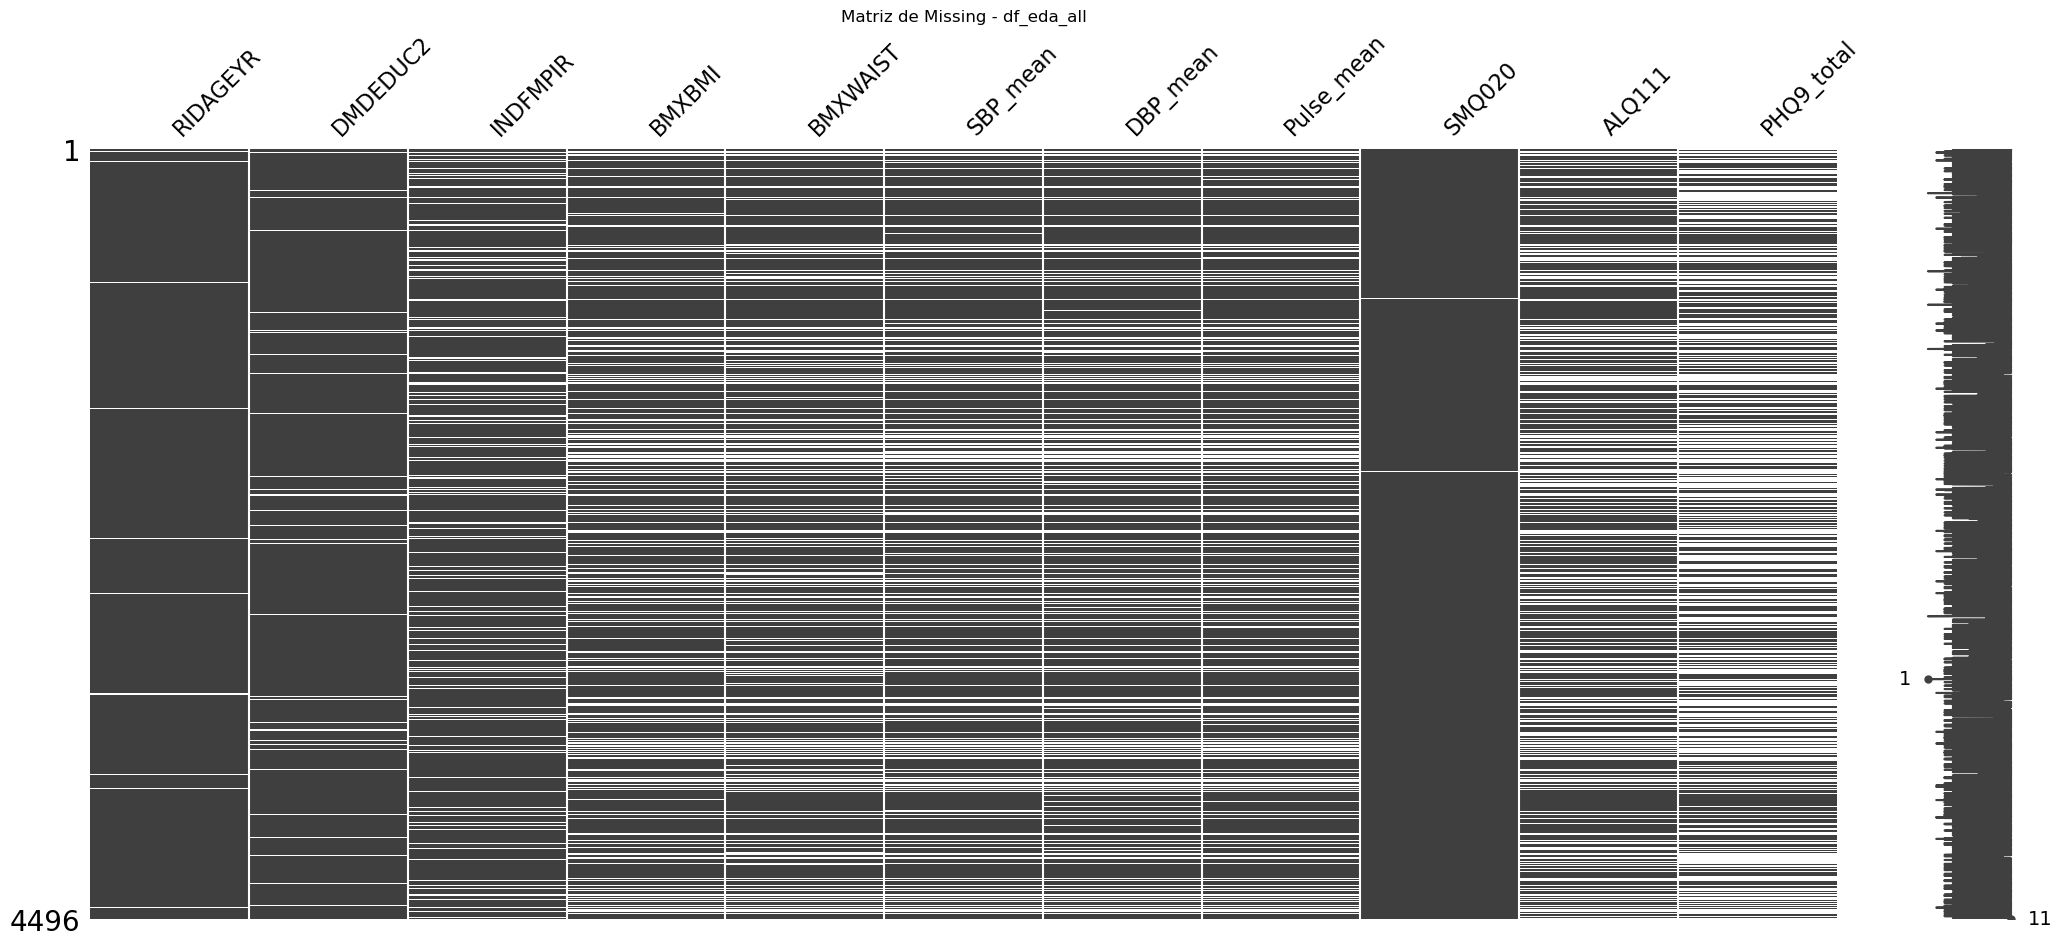

In [8]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
msno.matrix(df_eda_all)
plt.title("Matriz de Missing - df_eda_all")
plt.show()

### CORRELACIÓN ENTRE MISSINGS

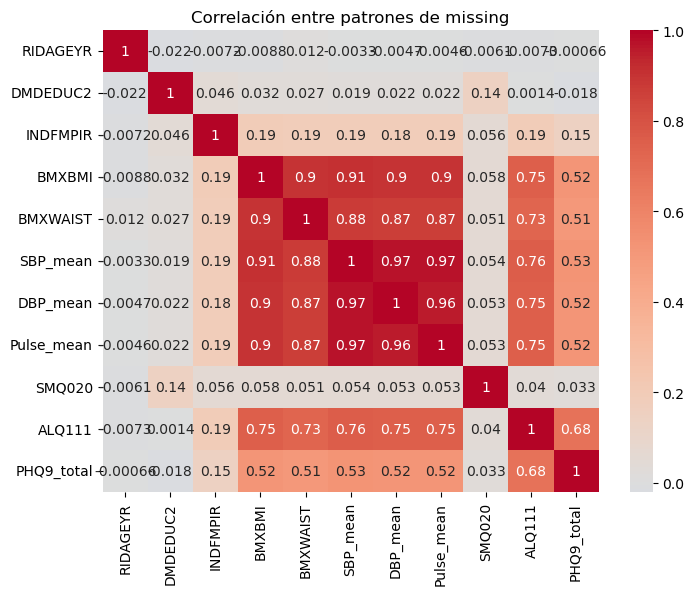

In [9]:
missing_binary = df_eda_all.isna().astype(int)

missing_corr = missing_binary.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(missing_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre patrones de missing")
plt.show()

In [10]:
# Calidad del dato y revisión de missing

# En esta fase no se eliminan observaciones.
# Primero se analiza el patrón de missing y su posible impacto.

# Subset opcional con PHQ-9 completo

if "PHQ9_total" in df_eda_all.columns:

    df_eda_phq = df_eda_all.dropna(
        subset=["PHQ9_total"]
    ).copy()

else:
    df_eda_phq = df_eda_all.copy()


print(
    "N filas df_eda_all:",
    df_eda_all.shape[0]
)

print(
    "N filas df_eda_phq:",
    df_eda_phq.shape[0]
)

print(
    "Filas excluidas por PHQ9 incompleto:",
    df_eda_all.shape[0] - df_eda_phq.shape[0]
)


# Variables con porcentaje elevado de missing

threshold_review = 30

vars_review = (
    missing_table.loc[
        missing_table["Missing_%"] >= threshold_review,
        "Variable"
    ]
    .tolist()
)

print("\nVariables bajo revisión por missing elevado:")

for v in vars_review:

    pct = float(
        missing_table.loc[
            missing_table["Variable"] == v,
            "Missing_%"
        ].values[0]
    )

    print(f"- {v}: {pct:.2f}%")

N filas df_eda_all: 4496
N filas df_eda_phq: 2188
Filas excluidas por PHQ9 incompleto: 2308

Variables bajo revisión por missing elevado:
- PHQ9_total: 51.33%
- ALQ111: 33.90%


In [ ]:
# Clasificación de variables según porcentaje de missing
threshold_review = 30
threshold_high = 50


# Missing alto
vars_high_missing = (
    missing_table.loc[
        missing_table["Missing_%"] >= threshold_high,
        "Variable"
    ]
    .tolist()
)


# Missing moderado
vars_review_missing = (
    missing_table.loc[
        (missing_table["Missing_%"] >= threshold_review) &
        (missing_table["Missing_%"] < threshold_high),
        "Variable"
    ]
    .tolist()
)


# Missing bajo
vars_low_missing = (
    missing_table.loc[
        missing_table["Missing_%"] < threshold_review,
        "Variable"
    ]
    .tolist()
)


print("\nVariables con missing >= 50%:")

for v in vars_high_missing:

    pct = float(
        missing_table.loc[
            missing_table["Variable"] == v,
            "Missing_%"
        ].iloc[0]
    )

    print(f"- {v}: {pct:.2f}%")


print("\nVariables con missing entre 30% y 50%:")

for v in vars_review_missing:

    pct = float(
        missing_table.loc[
            missing_table["Variable"] == v,
            "Missing_%"
        ].iloc[0]
    )

    print(f"- {v}: {pct:.2f}%")


print("\nVariables con missing < 30%:")

for v in vars_low_missing:

    pct = float(
        missing_table.loc[
            missing_table["Variable"] == v,
            "Missing_%"
        ].iloc[0]
    )

    print(f"- {v}: {pct:.2f}%")


# En esta fase no se eliminan variables automáticamente
variables_eliminadas = []

print("\nVariables eliminadas en esta fase:")
print(variables_eliminadas)

print("\nNo se eliminan variables durante la fase diagnóstica.")
print("Las variables con missing elevado se revisarán")
print("en etapas posteriores del análisis.")


Variables con missing >= 50%:
- PHQ9_total: 51.33%

Variables con missing entre 30% y 50%:
- ALQ111: 33.90%

Variables con missing < 30%:
- BMXWAIST: 27.45%
- DBP_mean: 26.45%
- Pulse_mean: 26.40%
- SBP_mean: 25.87%
- BMXBMI: 23.98%
- INDFMPIR: 16.84%
- DMDEDUC2: 4.16%
- RIDAGEYR: 1.09%
- SMQ020: 0.33%

Variables eliminadas en esta fase:
[]

No se eliminan variables durante la fase diagnóstica.
Las variables con missing elevado se revisarán
en etapas posteriores del análisis.


#### COMPLEMENTAR EL DICCIONARIO TÉCNICO


In [15]:
import pandas as pd
import numpy as np

path_dic = r"C:\Users\carme\OneDrive\Desktop\TFG\diccionario_variables_TFG.csv"

dic = pd.read_csv(path_dic)

print(dic.columns)

dic = dic.rename(columns={
    "Variable": "variable",
    "Descripción": "description",
    "Tipo": "type"
})

# creo columnas 

units = {
    "RIDAGEYR": "years",
    "DMDEDUC2": "category code",
    "INDFMPIR": "ratio",
    "BMXBMI": "kg/m^2",
    "BMXWAIST": "cm"
}

theoretical_range = {
    "RIDAGEYR": "[18, +)",
    "INDFMPIR": "approx [0, 5]",
    "BMXBMI": "approx [10, 80]",
    "BMXWAIST": "approx [40, 200]",
    "DMDEDUC2": "1–5 + 7/9 special"
}

nhanes_coding = {
    "DMDEDUC2": {
        1: "Less than 9th grade",
        2: "9-11th grade (incl. 12th no diploma)",
        3: "High school graduate/GED",
        4: "Some college or AA degree",
        5: "College graduate or above",
        7: "Refused",
        9: "Don't know"
    }
}

recoding_rules = {
    "GENERAL": "NHANES special codes 7/9/77/99 recoded to NA where applicable."
}

def coding_to_text(var):
    if var not in nhanes_coding:
        return "Not applicable / continuous"
    return "; ".join([f"{k}={v}" for k, v in nhanes_coding[var].items()])

dic["unit"] = dic["variable"].map(units).fillna("")
dic["theoretical_range"] = dic["variable"].map(theoretical_range).fillna("")
dic["nhanes_original_coding"] = dic["variable"].apply(coding_to_text)
dic["recoding_rules"] = dic["variable"].map(recoding_rules).fillna(recoding_rules["GENERAL"])

dic.head()


Index(['Variable', 'Descripción', 'Tipo'], dtype='object')


,variable,description,type,unit,theoretical_range,nhanes_original_coding,recoding_rules
0,RIDAGEYR,Edad,Numérica continua,years,"[18, +)",Not applicable / continuous,NHANES special codes 7/9/77/99 recoded to NA w...
1,DMDEDUC2,Nivel educativo (ordinal),Categórica ordinal,category code,1–5 + 7/9 special,1=Less than 9th grade; 2=9-11th grade (incl. 1...,NHANES special codes 7/9/77/99 recoded to NA w...
2,INDFMPIR,Ratio ingreso familiar,Numérica continua,ratio,"approx [0, 5]",Not applicable / continuous,NHANES special codes 7/9/77/99 recoded to NA w...
3,BMXBMI,Índice de masa corporal (BMI),Numérica continua,kg/m^2,"approx [10, 80]",Not applicable / continuous,NHANES special codes 7/9/77/99 recoded to NA w...
4,BMXWAIST,Circunferencia de cintura,Numérica continua,cm,"approx [40, 200]",Not applicable / continuous,NHANES special codes 7/9/77/99 recoded to NA w...


In [16]:
import pandas as pd

path_dic = r"C:\Users\carme\OneDrive\Desktop\TFG\diccionario_variables_TFG.csv"
dic = pd.read_csv(path_dic)

dic = dic.rename(columns={"Variable": "variable", "Descripción": "description", "Tipo": "type"})

units = {
    "RIDAGEYR": "years",
    "DMDEDUC2": "category code",
    "INDFMPIR": "ratio",
    "BMXBMI": "kg/m^2",
    "BMXWAIST": "cm"
}

theoretical_range = {
    "RIDAGEYR": "[18, +)",
    "INDFMPIR": "approx [0, 5]",
    "BMXBMI": "approx [10, 80]",
    "BMXWAIST": "approx [40, 200]",
    "DMDEDUC2": "1–5 + 7/9 special"
}

nhanes_coding = {
    "DMDEDUC2": {
        1: "Less than 9th grade",
        2: "9-11th grade (incl. 12th no diploma)",
        3: "High school graduate/GED",
        4: "Some college or AA degree",
        5: "College graduate or above",
        7: "Refused",
        9: "Don't know"
    }
}

recoding_rules = {
    "GENERAL": "NHANES special codes 7/9/77/99/777/999 recoded to NA where applicable."
}

def coding_to_text(var: str) -> str:
    if var not in nhanes_coding:
        return "Not applicable / continuous"
    return "; ".join([f"{k}={v}" for k, v in nhanes_coding[var].items()])

dic_tecnico = dic.copy()
dic_tecnico["unit"] = dic_tecnico["variable"].map(units).fillna("")
dic_tecnico["theoretical_range"] = dic_tecnico["variable"].map(theoretical_range).fillna("")
dic_tecnico["nhanes_original_coding"] = dic_tecnico["variable"].apply(coding_to_text)
dic_tecnico["recoding_rules"] = dic_tecnico["variable"].map(recoding_rules).fillna(recoding_rules["GENERAL"])


dic_tecnico

,variable,description,type,unit,theoretical_range,nhanes_original_coding,recoding_rules
0,RIDAGEYR,Edad,Numérica continua,years,"[18, +)",Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
1,DMDEDUC2,Nivel educativo (ordinal),Categórica ordinal,category code,1–5 + 7/9 special,1=Less than 9th grade; 2=9-11th grade (incl. 1...,NHANES special codes 7/9/77/99/777/999 recoded...
2,INDFMPIR,Ratio ingreso familiar,Numérica continua,ratio,"approx [0, 5]",Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
3,BMXBMI,Índice de masa corporal (BMI),Numérica continua,kg/m^2,"approx [10, 80]",Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
4,BMXWAIST,Circunferencia de cintura,Numérica continua,cm,"approx [40, 200]",Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
5,SBP_mean,Presión arterial sistólica media (mmHg),Numérica continua,,,Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
6,DBP_mean,Presión arterial diastólica media (mmHg),Numérica continua,,,Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
7,Pulse_mean,Pulso medio (lpm),Numérica continua,,,Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
8,SMQ020,Fuma actualmente,Binaria / categórica,,,Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...
9,ALQ111,Consumo de alcohol,Binaria / categórica,,,Not applicable / continuous,NHANES special codes 7/9/77/99/777/999 recoded...


## RECODIFICACIÓN FORMAL DE VARIABLES CATEGÓRICAS

### PREPARACIÓN Y COMPROBAR QUE EXISTEN LAS COLUMNAS 


In [17]:

import pandas as pd
import numpy as np

df = df_eda_all.copy()

needed = ["DMDEDUC2", "SMQ020", "ALQ111"]
missing_cols = [c for c in needed if c not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan estas columnas en tu dataframe: {missing_cols}")

for c in needed:
    print("\n", c, "valores únicos (incluyendo NA):")
    print(df[c].value_counts(dropna=False).sort_index())


 DMDEDUC2 valores únicos (incluyendo NA):
DMDEDUC2
1.0     202
2.0     350
3.0     904
4.0    1394
5.0    1459
NaN     187
Name: count, dtype: int64

 SMQ020 valores únicos (incluyendo NA):
SMQ020
1.0    1539
2.0    2942
NaN      15
Name: count, dtype: int64

 ALQ111 valores únicos (incluyendo NA):
ALQ111
1.0    2645
2.0     327
NaN    1524
Name: count, dtype: int64


### RECODIFICAR DMDEDUC2 COMO ORDINAL ETIQUETADA (nivel educativo)

In [18]:
# Nivel educativo (DMDEDUC2)

df["DMDEDUC2"] = pd.to_numeric(
    df["DMDEDUC2"],
    errors="coerce"
)

# Recodificación de valores especiales
df.loc[
    df["DMDEDUC2"].isin([7, 9]),
    "DMDEDUC2"
] = np.nan

# Etiquetas ordinales
edu_order = [
    "Less than 9th grade",
    "9-11th grade",
    "High school graduate/GED",
    "Some college or AA degree",
    "College graduate or above"
]

edu_map = {
    1: edu_order[0],
    2: edu_order[1],
    3: edu_order[2],
    4: edu_order[3],
    5: edu_order[4]
}

# Conversión a etiquetas
df["DMDEDUC2_label"] = df["DMDEDUC2"].map(
    edu_map
)

# Conversión a variable ordinal
df["DMDEDUC2_label"] = pd.Categorical(
    df["DMDEDUC2_label"],
    categories=edu_order,
    ordered=True
)

# Verificación
print("\nRecuento DMDEDUC2:")

print(
    df["DMDEDUC2_label"].value_counts(
        dropna=False
    )
)

print("\nTipo de variable:")

print(df["DMDEDUC2_label"].dtype)


Recuento DMDEDUC2:
DMDEDUC2_label
College graduate or above    1459
Some college or AA degree    1394
High school graduate/GED      904
9-11th grade                  350
Less than 9th grade           202
NaN                           187
Name: count, dtype: int64

Tipo de variable:
category


### RECODIFICAR SMQ020 (Fuma actualmente) y ALQ111 (Consumo de alcohol) A categCATEGORÍAS INTERPRETABLES

In [19]:
def recode_yes_no(series: pd.Series, name: str) -> pd.Categorical:
    """
    Recodifica variables NHANES tipo 1=Yes, 2=No, 7/9=missing
    a categórica con etiquetas 'Yes'/'No' (NA si códigos especiales).
    """
    s = pd.to_numeric(series, errors="coerce")
    s = s.where(~s.isin([7, 9]), np.nan)  # 7/9 -> NA

    mapped = s.map({1: "Yes", 2: "No"})
    out = pd.Categorical(mapped, categories=["No", "Yes"], ordered=True)

    # Mini diagnóstico
    print(f"\n{name} después de recodificar:")
    print(pd.Series(out).value_counts(dropna=False))
    return out

df["SMQ020_label"] = recode_yes_no(df["SMQ020"], "SMQ020 (Smoking: >=100 cigarettes lifetime?)")
df["ALQ111_label"] = recode_yes_no(df["ALQ111"], "ALQ111 (Alcohol: at least 12 drinks/year?)")


SMQ020 (Smoking: >=100 cigarettes lifetime?) después de recodificar:
No     2942
Yes    1539
NaN      15
Name: count, dtype: int64

ALQ111 (Alcohol: at least 12 drinks/year?) después de recodificar:
Yes    2645
NaN    1524
No      327
Name: count, dtype: int64


### VERIFICAR COHERENCIA

In [20]:
def check_binary_coherence(series: pd.Series, allowed={1,2,7,9}, varname="VAR"):
    s = pd.to_numeric(series, errors="coerce")
    observed = set(s.dropna().unique())
    unexpected = observed - allowed

    print(f"\nChequeo coherencia {varname}:")
    print("Valores observados:", sorted(observed))
    if unexpected:
        print("⚠️ Valores inesperados detectados:", sorted(unexpected))
        print("   -> Revisa el codebook NHANES o si has mezclado variables.")
    else:
        print("✅ OK: solo aparecen valores esperados", sorted(allowed))

check_binary_coherence(df["SMQ020"], varname="SMQ020")
check_binary_coherence(df["ALQ111"], varname="ALQ111")


Chequeo coherencia SMQ020:
Valores observados: [np.float64(1.0), np.float64(2.0)]
✅ OK: solo aparecen valores esperados [1, 2, 7, 9]

Chequeo coherencia ALQ111:
Valores observados: [np.float64(1.0), np.float64(2.0)]
✅ OK: solo aparecen valores esperados [1, 2, 7, 9]


### COMPROBACIÓN DE QUE NO ME FALTA NINGUNA VARIABLE POR RECODIFICAR 

In [21]:
for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 10:
            print(col, "-> posibles códigos:", sorted(unique_vals))

DMDEDUC2 -> posibles códigos: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
SMQ020 -> posibles códigos: [np.float64(1.0), np.float64(2.0)]
ALQ111 -> posibles códigos: [np.float64(1.0), np.float64(2.0)]


## ANÁLISIS MULTIVARIANTE

In [22]:
import numpy as np
import pandas as pd

# Dataset para análisis
df_analysis = df_eda_all.copy()

# Nivel educativo
df_analysis["DMDEDUC2"] = pd.to_numeric(
    df_analysis["DMDEDUC2"],
    errors="coerce"
)

df_analysis.loc[
    ~df_analysis["DMDEDUC2"].isin([1, 2, 3, 4, 5]),
    "DMDEDUC2"
] = np.nan

edu_order = [
    "Less than 9th grade",
    "9-11th grade",
    "High school graduate/GED",
    "Some college or AA degree",
    "College graduate or above"
]

edu_map = {
    1: edu_order[0],
    2: edu_order[1],
    3: edu_order[2],
    4: edu_order[3],
    5: edu_order[4]
}

df_analysis["DMDEDUC2_label"] = df_analysis["DMDEDUC2"].map(edu_map)

df_analysis["DMDEDUC2_label"] = pd.Categorical(
    df_analysis["DMDEDUC2_label"],
    categories=edu_order,
    ordered=True
)

# Variables binarias
def recode_yes_no(series):

    s = pd.to_numeric(series, errors="coerce")

    s.loc[~s.isin([1, 2])] = np.nan

    mapped = s.map({
        1: "Yes",
        2: "No"
    })

    return pd.Categorical(
        mapped,
        categories=["No", "Yes"],
        ordered=True
    )

df_analysis["SMQ020_label"] = recode_yes_no(df_analysis["SMQ020"])

df_analysis["ALQ111_label"] = recode_yes_no(df_analysis["ALQ111"])

# Eliminación de variables originales
df_analysis = df_analysis.drop(
    columns=["DMDEDUC2", "SMQ020", "ALQ111"],
    errors="ignore"
)

# Comprobación
print("Variables label en df_analysis:")

print([
    c for c in df_analysis.columns
    if "label" in c
])

print("\nTipos de variables:")

print(
    df_analysis[
        [
            "DMDEDUC2_label",
            "SMQ020_label",
            "ALQ111_label"
        ]
    ].dtypes
)

Variables label en df_analysis:
['DMDEDUC2_label', 'SMQ020_label', 'ALQ111_label']

Tipos de variables:
DMDEDUC2_label    category
SMQ020_label      category
ALQ111_label      category
dtype: object


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset de trabajo
df = df_eda_all.copy()

# Variables categóricas

if "DMDEDUC2_label" not in df.columns:

    df["DMDEDUC2"] = pd.to_numeric(
        df["DMDEDUC2"],
        errors="coerce"
    )

    df.loc[
        ~df["DMDEDUC2"].isin([1, 2, 3, 4, 5]),
        "DMDEDUC2"
    ] = np.nan

    edu_order = [
        "Less than 9th grade",
        "9-11th grade",
        "High school graduate/GED",
        "Some college or AA degree",
        "College graduate or above"
    ]

    edu_map = {
        1: edu_order[0],
        2: edu_order[1],
        3: edu_order[2],
        4: edu_order[3],
        5: edu_order[4]
    }

    df["DMDEDUC2_label"] = df["DMDEDUC2"].map(
        edu_map
    )

    df["DMDEDUC2_label"] = pd.Categorical(
        df["DMDEDUC2_label"],
        categories=edu_order,
        ordered=True
    )


# Función yes/no

def recode_yes_no(series):

    s = pd.to_numeric(
        series,
        errors="coerce"
    )

    s.loc[~s.isin([1, 2])] = np.nan

    mapped = s.map({
        1: "Yes",
        2: "No"
    })

    return pd.Categorical(
        mapped,
        categories=["No", "Yes"],
        ordered=True
    )


# Variables binarias

if "SMQ020_label" not in df.columns and "SMQ020" in df.columns:

    df["SMQ020_label"] = recode_yes_no(
        df["SMQ020"]
    )

if "ALQ111_label" not in df.columns and "ALQ111" in df.columns:

    df["ALQ111_label"] = recode_yes_no(
        df["ALQ111"]
    )


# Variables categóricas y numéricas

cat_cols = [
    c for c in [
        "DMDEDUC2_label",
        "SMQ020_label",
        "ALQ111_label"
    ]
    if c in df.columns
]

exclude_codes = [
    c for c in [
        "DMDEDUC2",
        "SMQ020",
        "ALQ111"
    ]
    if c in df.columns
]

num_cols = [
    c for c in df.select_dtypes(
        include=["number"]
    ).columns.tolist()
    if c not in exclude_codes
]

print("Numéricas:")
print(num_cols)

print("\nCategóricas:")
print(cat_cols)


# Tabla descriptiva numérica

def numeric_univariate_table(
    df,
    cols,
    percentiles=(0.01, 0.05, 0.95, 0.99)
):

    rows = []

    for c in cols:

        s = pd.to_numeric(
            df[c],
            errors="coerce"
        )

        n = s.notna().sum()

        miss = s.isna().sum()

        miss_pct = miss / len(s) * 100

        q1 = s.quantile(0.25)

        q3 = s.quantile(0.75)

        iqr = q3 - q1

        pct_vals = {
            f"p{int(p*100)}": s.quantile(p)
            for p in percentiles
        }

        rows.append({
            "variable": c,
            "n": n,
            "missing": miss,
            "missing_%": miss_pct,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            **pct_vals
        })

    return (
        pd.DataFrame(rows)
        .sort_values("missing_%", ascending=False)
        .reset_index(drop=True)
    )


# Tabla final

num_table = numeric_univariate_table(
    df,
    num_cols
)

print("\nTabla descriptiva numérica:")

print(num_table)

Numéricas:
['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'SBP_mean', 'DBP_mean', 'Pulse_mean', 'PHQ9_total']

Categóricas:
['DMDEDUC2_label', 'SMQ020_label', 'ALQ111_label']

Tabla descriptiva numérica:
     variable     n  missing  missing_%        mean      median        std  \
0  PHQ9_total  2188     2308  51.334520    6.121572    4.000000   5.701044   
1    BMXWAIST  3262     1234  27.446619   98.536665   96.700000  17.286169   
2    DBP_mean  3307     1189  26.445730   73.833938   73.000000  10.903632   
3  Pulse_mean  3309     1187  26.401246   72.946258   72.000000  11.754607   
4    SBP_mean  3333     1163  25.867438  120.470197  116.666667  18.747021   
5      BMXBMI  3418     1078  23.976868   30.132153   28.600000   8.006950   
6    INDFMPIR  3739      757  16.837189    2.761081    2.570000   1.661946   
7    RIDAGEYR  4447       49   1.089858   51.852710   54.000000  18.339654   

           Q1          Q3        IQR         p1         p5         p95  \
0    2.000000    8.

### HISTOGRAMAS 


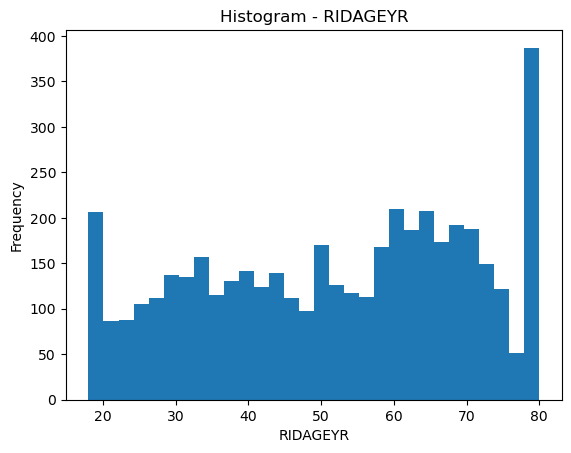

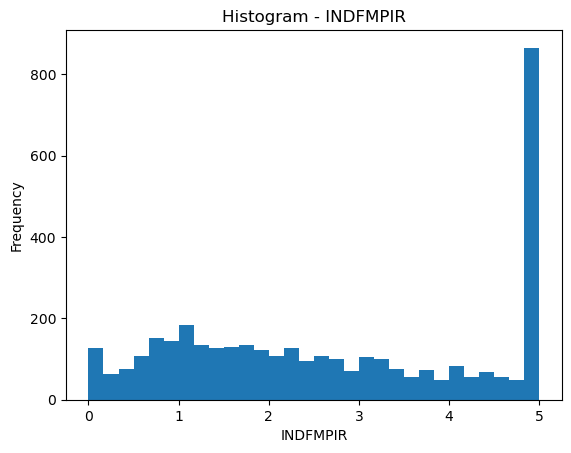

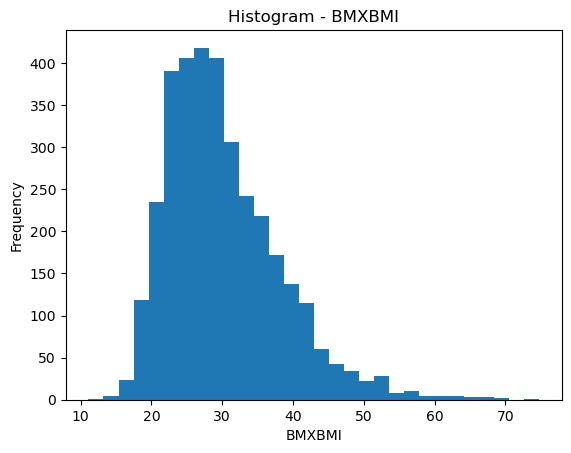

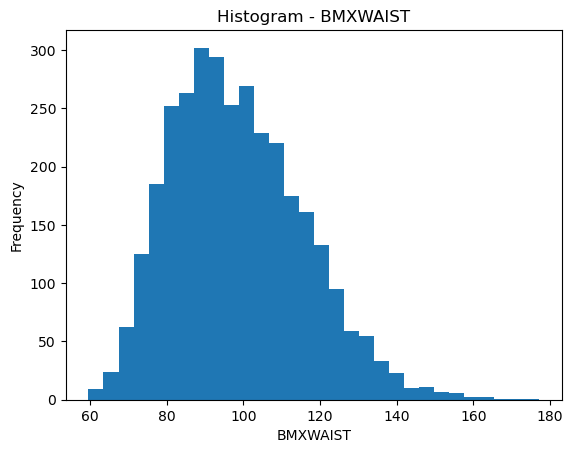

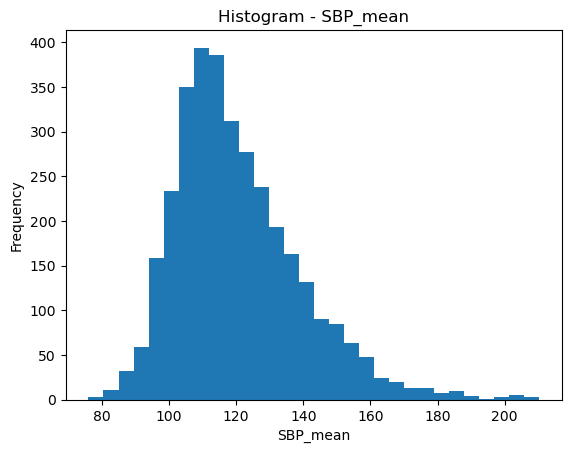

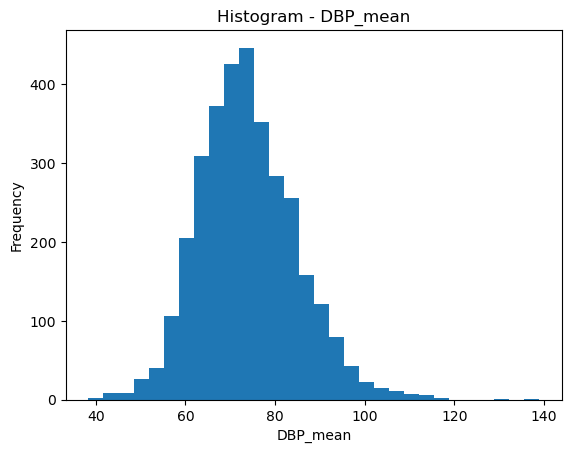

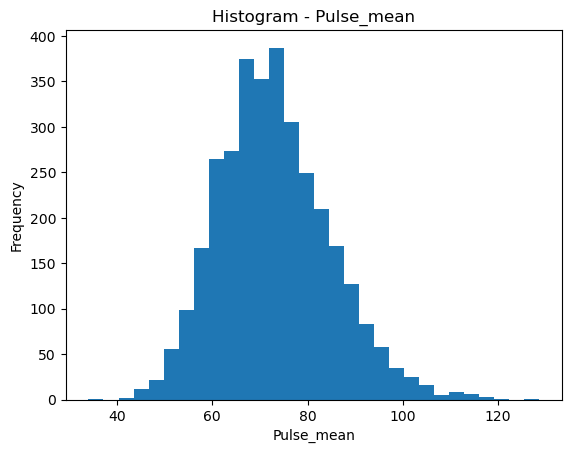

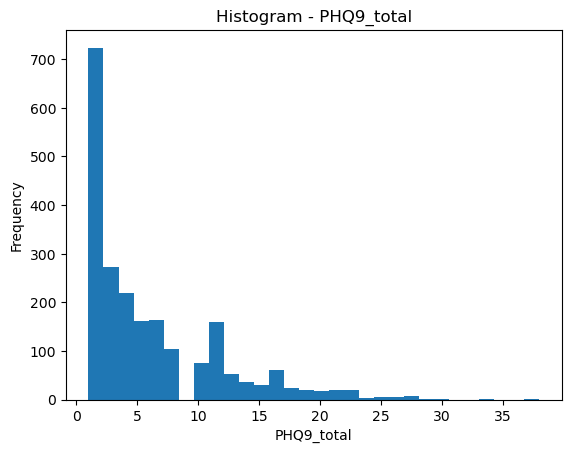

In [25]:
def plot_histograms(df, cols, bins=30):
    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.empty:
            print(f"[{c}] Todo NA -> no se grafica.")
            continue

        plt.figure()
        plt.hist(s, bins=bins)
        plt.title(f"Histogram - {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")
        plt.show()

plot_histograms(df, num_cols, bins=30)

### BOXPLOT

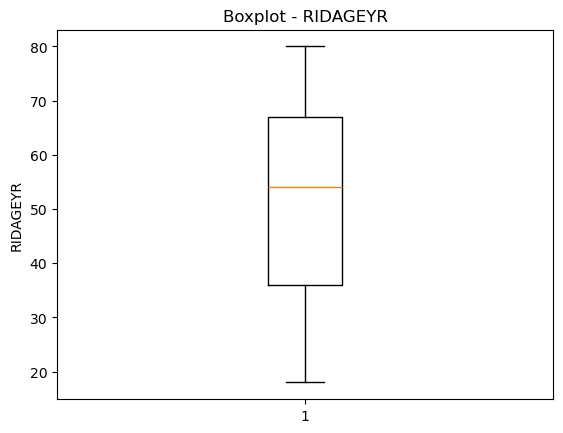

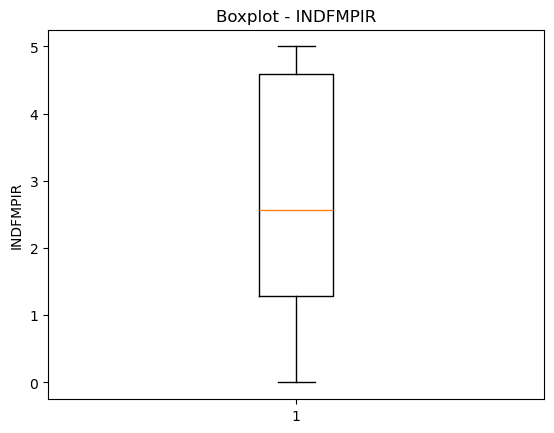

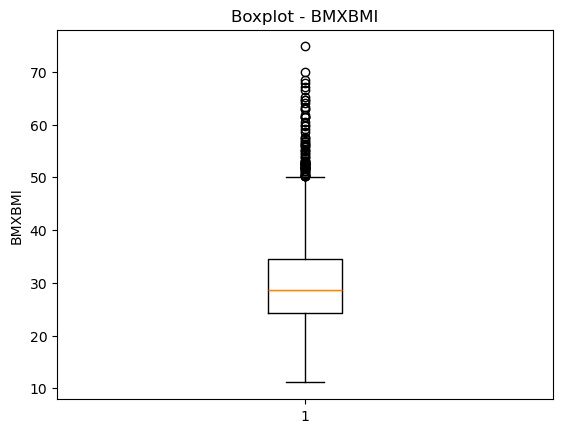

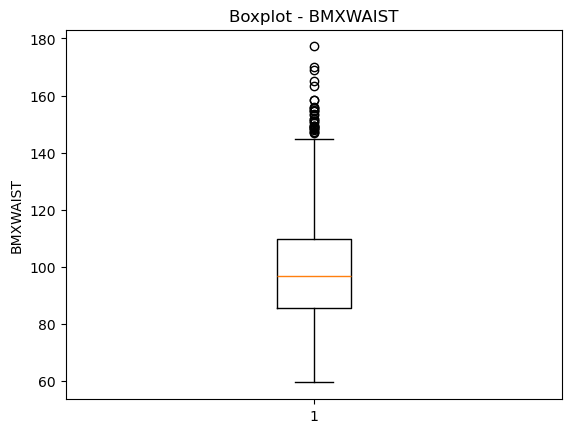

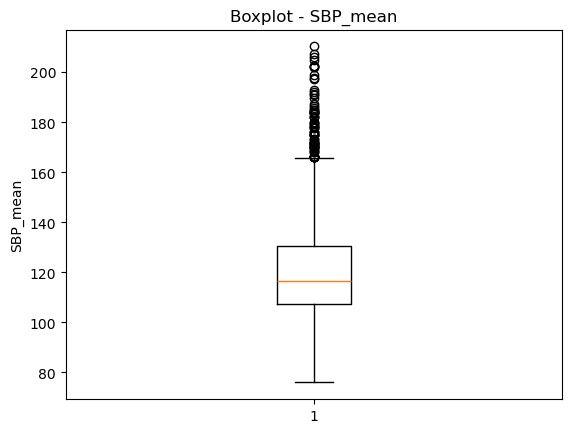

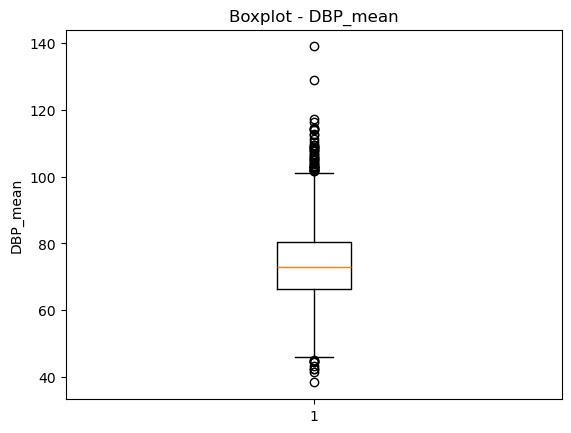

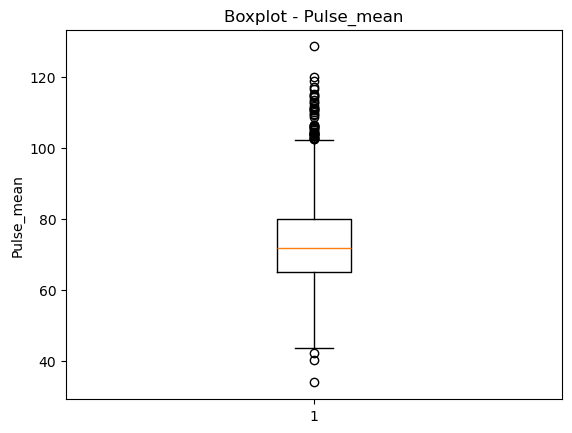

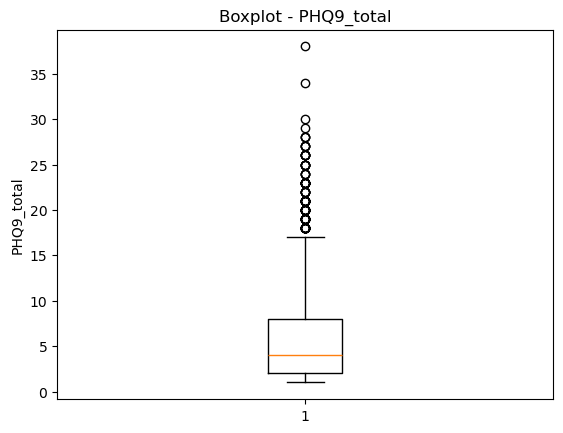

In [26]:
def plot_boxplots(df, cols):
    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.empty:
            print(f"[{c}] Todo NA -> no se grafica.")
            continue

        plt.figure()
        plt.boxplot(s, vert=True)
        plt.title(f"Boxplot - {c}")
        plt.ylabel(c)
        plt.show()

plot_boxplots(df, num_cols)

### VARIABLES CATEGÓRICAS

### TABLAS DE FRECUENCIAS Y PORCENTAJES

In [28]:
def categorical_univariate_tables(df, cols, include_na=True):

    out = {}
    for c in cols:
        vc = df[c].value_counts(dropna=not include_na)
        pct = df[c].value_counts(dropna=not include_na, normalize=True) * 100
        tab = pd.DataFrame({"count": vc, "percent_%": pct})
        out[c] = tab
    return out

cat_tables = categorical_univariate_tables(df, cat_cols, include_na=True)

for c in cat_cols:
    print("\n=== ", c, " ===")
    display(cat_tables[c])


===  DMDEDUC2_label  ===


,count,percent_%
DMDEDUC2_label,,
College graduate or above,1459,32.451068
Some college or AA degree,1394,31.005338
High school graduate/GED,904,20.106762
9-11th grade,350,7.784698
Less than 9th grade,202,4.492883
NaN,187,4.159253



===  SMQ020_label  ===


,count,percent_%
SMQ020_label,,
No,2942,65.435943
Yes,1539,34.230427
NaN,15,0.333630



===  ALQ111_label  ===


,count,percent_%
ALQ111_label,,
Yes,2645,58.830071
NaN,1524,33.896797
No,327,7.273132


### GRÁFICO DE BARRAS

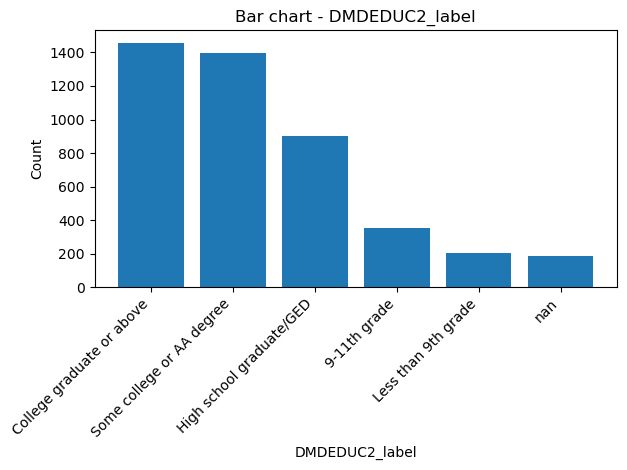

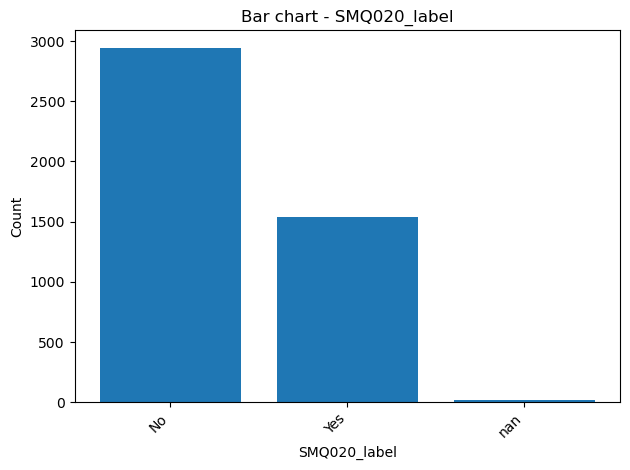

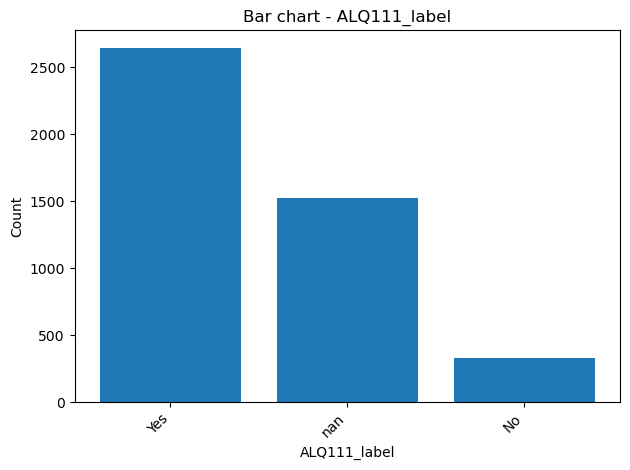

In [29]:
def plot_bar_charts(df, cols, include_na=True):
    for c in cols:
        vc = df[c].value_counts(dropna=not include_na)

        plt.figure()
        plt.bar(vc.index.astype(str), vc.values)
        plt.title(f"Bar chart - {c}")
        plt.xlabel(c)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

plot_bar_charts(df, cat_cols, include_na=True)

## IDENTIFICACIÓN Y TRATAMIENTO DE OUTLIERS

### 1) MÉTODO 1: OUTLIERS POR IQR (Q1 − 1.5·IQR, Q3 + 1.5·IQR)

In [31]:
def detect_outliers_iqr(s: pd.Series, k: float = 1.5):
    """
    Detecta outliers por regla IQR.
    Devuelve máscara booleana de outlier + límites.
    """
    s = pd.to_numeric(s, errors="coerce")
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (s < lower) | (s > upper)
    return mask, lower, upper, q1, q3, iqr

### 2) MÉTODO 2: OUTLIERS POR MAD (robusto)

In [ ]:
def detect_outliers_mad(s: pd.Series, z_thresh: float = 3.5):
    """
    Detecta outliers con z-score robusto usando MAD.
    (Regla típica: |z_robust| > 3.5)
    """
    s = pd.to_numeric(s, errors="coerce")
    median = s.median()
    mad = (np.abs(s - median)).median()

    if mad == 0 or np.isnan(mad):
        mask = pd.Series(False, index=s.index)
        return mask, median, mad, np.nan

    z_robust = 0.6745 * (s - median) / mad
    mask = np.abs(z_robust) > z_thresh
    return mask, median, mad, z_robust

### 3) CUANTIFICAR OUTLIERS (n y %) POR VARIABLE CON AMBOS MÉTODOS 

In [33]:
def outlier_summary(df: pd.DataFrame, cols: list, iqr_k=1.5, mad_thresh=3.5):
    rows = []

    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce")
        n_nonmiss = s.notna().sum()
        if n_nonmiss == 0:
            rows.append({
                "variable": c, "n": 0,
                "iqr_outliers_n": np.nan, "iqr_outliers_%": np.nan,
                "mad_outliers_n": np.nan, "mad_outliers_%": np.nan,
                "iqr_lower": np.nan, "iqr_upper": np.nan
            })
            continue

        # IQR
        iqr_mask, lower, upper, q1, q3, iqr = detect_outliers_iqr(s, k=iqr_k)
        iqr_n = int(iqr_mask.sum())
        iqr_pct = iqr_n / n_nonmiss * 100

        # MAD
        mad_mask, med, mad, zrob = detect_outliers_mad(s, z_thresh=mad_thresh)
        mad_n = int(mad_mask.sum())
        mad_pct = mad_n / n_nonmiss * 100

        rows.append({
            "variable": c,
            "n": int(n_nonmiss),
            "iqr_outliers_n": iqr_n,
            "iqr_outliers_%": iqr_pct,
            "mad_outliers_n": mad_n,
            "mad_outliers_%": mad_pct,
            "iqr_lower": lower,
            "iqr_upper": upper
        })

    return pd.DataFrame(rows).sort_values("iqr_outliers_%", ascending=False).reset_index(drop=True)

out_table = outlier_summary(df, num_cols, iqr_k=1.5, mad_thresh=3.5)
out_table

,variable,n,iqr_outliers_n,iqr_outliers_%,mad_outliers_n,mad_outliers_%,iqr_lower,iqr_upper
0,PHQ9_total,2188,128,5.850091,219,10.009141,-7.000000,17.000000
1,BMXBMI,3418,80,2.340550,36,1.053248,8.850000,50.050000
2,SBP_mean,3333,78,2.340234,47,1.410141,72.333333,165.666667
3,DBP_mean,3307,59,1.784094,14,0.423344,45.333333,101.333333
4,Pulse_mean,3309,50,1.511031,13,0.392868,42.500000,102.500000
5,BMXWAIST,3262,31,0.950337,5,0.153280,49.187500,146.287500
6,RIDAGEYR,4447,0,0.000000,0,0.000000,-10.500000,113.500000
7,INDFMPIR,3739,0,0.000000,0,0.000000,-3.685000,9.555000


### VISUALIZAR OUTLIERS

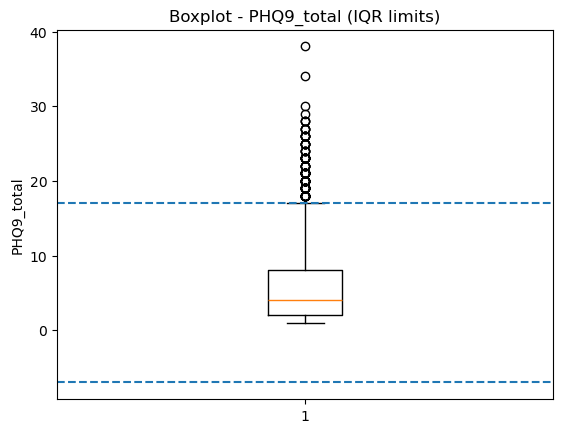

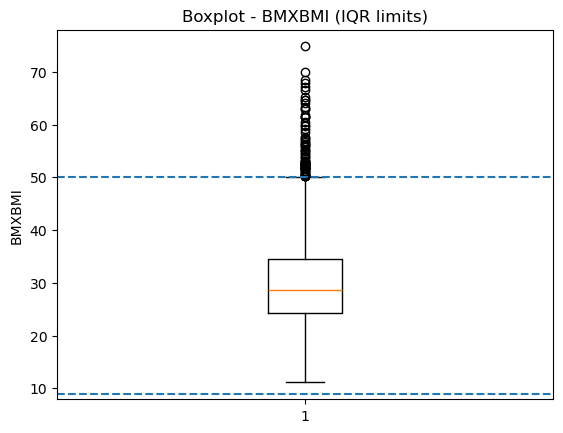

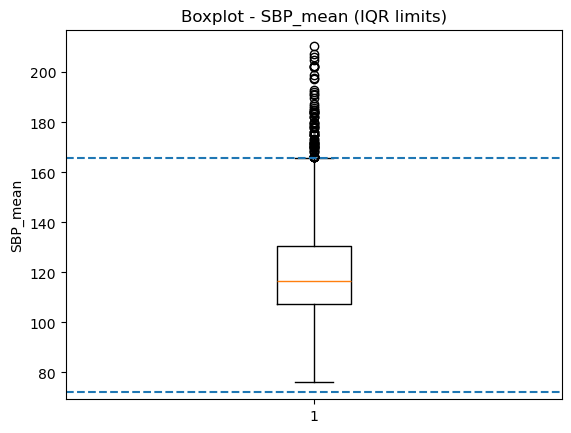

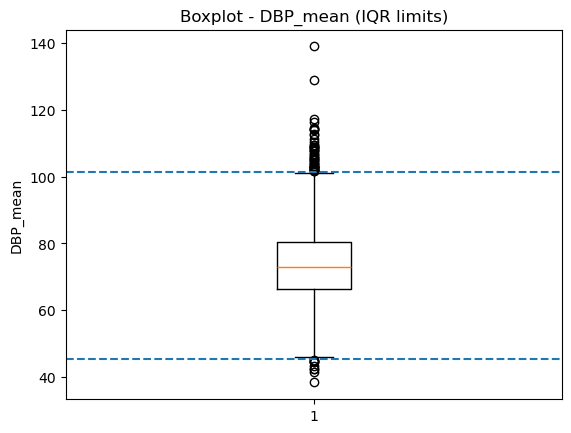

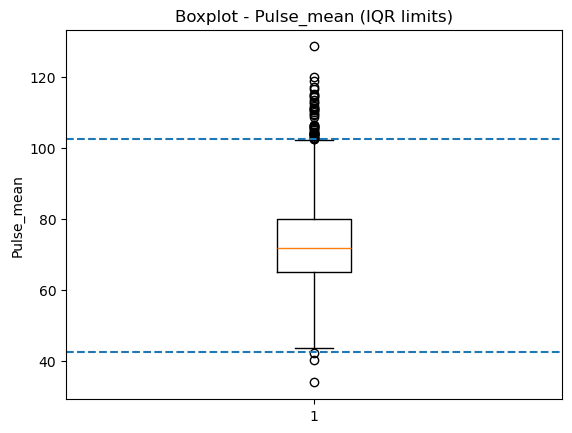

In [34]:
def plot_boxplot_with_iqr_limits(df, col, iqr_k=1.5):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if s.empty:
        print(f"[{col}] Todo NA.")
        return

    mask, lower, upper, q1, q3, iqr = detect_outliers_iqr(s, k=iqr_k)

    plt.figure()
    plt.boxplot(s, vert=True)
    plt.title(f"Boxplot - {col} (IQR limits)")
    plt.ylabel(col)
    plt.axhline(lower, linestyle="--")
    plt.axhline(upper, linestyle="--")
    plt.show()

top5 = out_table["variable"].head(5).tolist()
for c in top5:
    plot_boxplot_with_iqr_limits(df, c)

### OPCIÓN A — ROBUSTSCALER

In [35]:
from sklearn.preprocessing import RobustScaler

X = df[num_cols].copy()

rob_scaler = RobustScaler()
X_rob = pd.DataFrame(
    rob_scaler.fit_transform(X),
    columns=num_cols,
    index=df.index
)

X_rob.head()

,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,SBP_mean,DBP_mean,Pulse_mean,PHQ9_total
2,-0.322581,-0.350453,0.106796,-0.131823,-0.328571,0.380952,0.622222,-0.333333
7,0.354839,0.734139,NaN,NaN,NaN,NaN,NaN,NaN
9,0.451613,-0.377644,1.359223,1.042225,1.057143,0.214286,0.466667,NaN
10,-0.870968,-0.531722,1.466019,0.898043,0.528571,1.904762,0.666667,NaN
12,-0.741935,-0.123867,1.689320,1.412976,-0.228571,0.119048,1.488889,NaN


### OPCIÓN B — WINSORIZACIÓN p1/p99 + StandardScaler 

In [36]:
from sklearn.preprocessing import StandardScaler

def winsorize_df(df_in: pd.DataFrame, cols: list, p_low=0.01, p_high=0.99):
    df_out = df_in.copy()
    limits = {}
    for c in cols:
        s = pd.to_numeric(df_out[c], errors="coerce")
        lo = s.quantile(p_low)
        hi = s.quantile(p_high)
        df_out[c] = s.clip(lower=lo, upper=hi)
        limits[c] = (float(lo), float(hi))
    return df_out, limits

# 1) Winsorizar
df_wins, wins_limits = winsorize_df(df[num_cols], num_cols, p_low=0.01, p_high=0.99)

# 2) Escalar estándar después
std_scaler = StandardScaler()
X_wins_std = pd.DataFrame(
    std_scaler.fit_transform(df_wins),
    columns=num_cols,
    index=df.index
)

X_wins_std.head()

,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,SBP_mean,DBP_mean,Pulse_mean,PHQ9_total
2,-0.428230,-0.813243,-0.049095,-0.293284,-0.624162,0.428711,0.734774,-0.731131
7,0.716958,1.347444,NaN,NaN,NaN,NaN,NaN,NaN
9,0.880557,-0.867410,1.615902,1.392354,1.148422,0.208008,0.531256,NaN
10,-1.355288,-1.174360,1.757879,1.185346,0.472282,2.446562,0.792923,NaN
12,-1.137156,-0.361846,2.054739,1.924661,-0.496244,0.081892,1.868662,NaN


### COMPARACIÓN OBJETIVA 

In [37]:
# % de valores modificados por winsorización
wins_changed = []
for c in num_cols:
    original = pd.to_numeric(df[c], errors="coerce")
    clipped  = pd.to_numeric(df_wins[c], errors="coerce")

    # Comparación: solo donde ambos no sean NA
    mask_valid = original.notna() & clipped.notna()
    changed = (original[mask_valid] != clipped[mask_valid]).sum()
    total = mask_valid.sum()

    wins_changed.append({
        "variable": c,
        "changed_n": int(changed),
        "changed_%": float(changed / total * 100) if total > 0 else np.nan,
        "p1": wins_limits[c][0],
        "p99": wins_limits[c][1]
    })

wins_changed_table = pd.DataFrame(wins_changed).sort_values("changed_%", ascending=False)
wins_changed_table

,variable,changed_n,changed_%,p1,p99
6,Pulse_mean,67,2.024781,49.360000,104.333333
3,BMXWAIST,66,2.023299,67.422000,143.478000
4,SBP_mean,67,2.010201,88.000000,179.120000
5,DBP_mean,65,1.965528,50.666667,103.666667
2,BMXBMI,67,1.960211,17.700000,54.932000
1,INDFMPIR,38,1.016315,0.013800,5.000000
7,PHQ9_total,17,0.776965,1.000000,25.000000
0,RIDAGEYR,0,0.000000,18.000000,80.000000


### COMPARACIÓN ÚTIL PARA EL PCA 

In [38]:
from sklearn.decomposition import PCA

def pca_explained_variance(X_scaled: pd.DataFrame, n_components=8):
    # PCA no acepta NA
    X_clean = X_scaled.dropna()
    pca = PCA(n_components=min(n_components, X_clean.shape[1]))
    pca.fit(X_clean)
    return pca.explained_variance_ratio_, X_clean.shape[0]

ev_rob, n_rob = pca_explained_variance(X_rob, n_components=8)
ev_wins, n_wins = pca_explained_variance(X_wins_std, n_components=8)

print("Filas usadas (Robust):", n_rob, " | Varianza explicada 1..:", np.round(ev_rob, 3))
print("Filas usadas (Wins+Std):", n_wins, " | Varianza explicada 1..:", np.round(ev_wins, 3))
print("\nAcumulada (Robust):", np.round(ev_rob.cumsum(), 3))
print("Acumulada (Wins+Std):", np.round(ev_wins.cumsum(), 3))

Filas usadas (Robust): 1771  | Varianza explicada 1..: [0.294 0.236 0.171 0.146 0.065 0.053 0.026 0.008]
Filas usadas (Wins+Std): 1771  | Varianza explicada 1..: [0.29  0.218 0.158 0.126 0.094 0.079 0.027 0.008]

Acumulada (Robust): [0.294 0.53  0.702 0.847 0.912 0.966 0.992 1.   ]
Acumulada (Wins+Std): [0.29  0.508 0.666 0.791 0.886 0.964 0.992 1.   ]


## ANÁLISIS BIVARIANTE

### MATRIZ DE CORRELACIÓN VARIABLES NUMÉRICAS

In [40]:
corr_pearson = df[num_cols].corr(method="pearson")
corr_pearson

,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,SBP_mean,DBP_mean,Pulse_mean,PHQ9_total
RIDAGEYR,1.000000,0.093945,0.017348,0.152486,0.497894,0.085205,-0.214738,-0.158026
INDFMPIR,0.093945,1.000000,-0.120358,-0.103879,-0.023702,-0.013448,-0.128313,-0.248648
BMXBMI,0.017348,-0.120358,1.000000,0.917565,0.058359,0.235674,0.080547,0.104869
BMXWAIST,0.152486,-0.103879,0.917565,1.000000,0.118125,0.246960,0.101295,0.100445
SBP_mean,0.497894,-0.023702,0.058359,0.118125,1.000000,0.589688,-0.096004,-0.082911
DBP_mean,0.085205,-0.013448,0.235674,0.246960,0.589688,1.000000,0.241350,-0.004295
Pulse_mean,-0.214738,-0.128313,0.080547,0.101295,-0.096004,0.241350,1.000000,0.146904
PHQ9_total,-0.158026,-0.248648,0.104869,0.100445,-0.082911,-0.004295,0.146904,1.000000


### CORRELACIÓN SPEARMAN

In [41]:
corr_spearman = df[num_cols].corr(method="spearman")
corr_spearman

,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,SBP_mean,DBP_mean,Pulse_mean,PHQ9_total
RIDAGEYR,1.000000,0.089155,0.043071,0.173087,0.518139,0.068784,-0.225663,-0.184410
INDFMPIR,0.089155,1.000000,-0.121428,-0.101063,-0.005274,-0.012301,-0.132351,-0.248887
BMXBMI,0.043071,-0.121428,1.000000,0.919502,0.099763,0.262973,0.071463,0.095401
BMXWAIST,0.173087,-0.101063,0.919502,1.000000,0.165662,0.269996,0.083326,0.092015
SBP_mean,0.518139,-0.005274,0.099763,0.165662,1.000000,0.585955,-0.106441,-0.112121
DBP_mean,0.068784,-0.012301,0.262973,0.269996,0.585955,1.000000,0.227152,0.000060
Pulse_mean,-0.225663,-0.132351,0.071463,0.083326,-0.106441,0.227152,1.000000,0.131107
PHQ9_total,-0.184410,-0.248887,0.095401,0.092015,-0.112121,0.000060,0.131107,1.000000


### HEATMAP DE CORRELACIONES

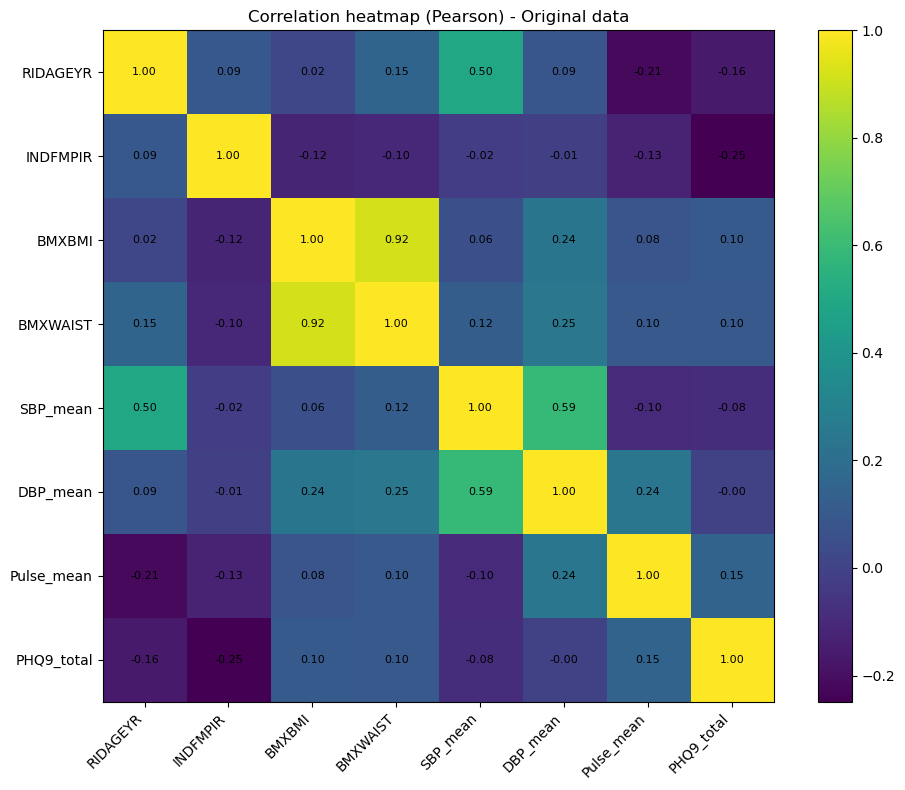

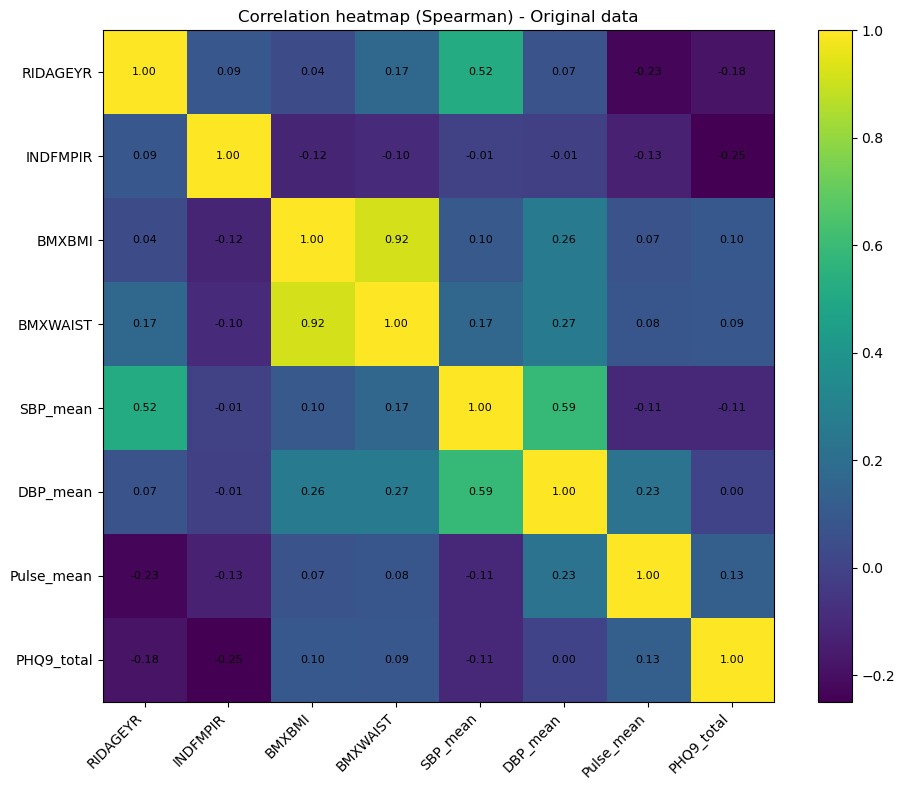

In [42]:
def plot_corr_heatmap(corr: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 8))
    plt.imshow(corr.values)
    plt.title(title)
    plt.colorbar()

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)

    # Anotar coeficientes dentro (redondeados)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            plt.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_corr_heatmap(corr_pearson, "Correlation heatmap (Pearson) - Original data")
plot_corr_heatmap(corr_spearman, "Correlation heatmap (Spearman) - Original data")

### SCATTERPLOTS CLÍNICAMENTE RELEVANTES 

#### FUNCIÓN PARA SCATTER + CORRELACIÓN EN EL TÍTULO 

In [43]:
def scatter_with_corr(df, x, y, method="pearson"):
    sub = df[[x, y]].dropna()
    if sub.empty:
        print(f"No hay datos suficientes para {x} vs {y}")
        return

    r = sub[x].corr(sub[y], method=method)

    plt.figure()
    plt.scatter(sub[x], sub[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x} | {method} r = {r:.2f}")
    plt.show()

#### SCATTERPLOTS RECOMENDADOS PARA EL TFG 

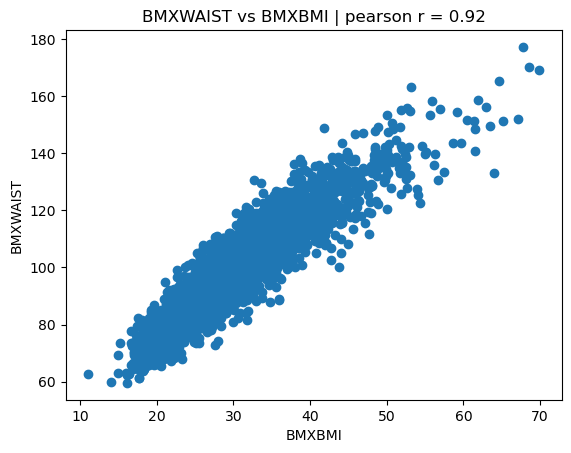

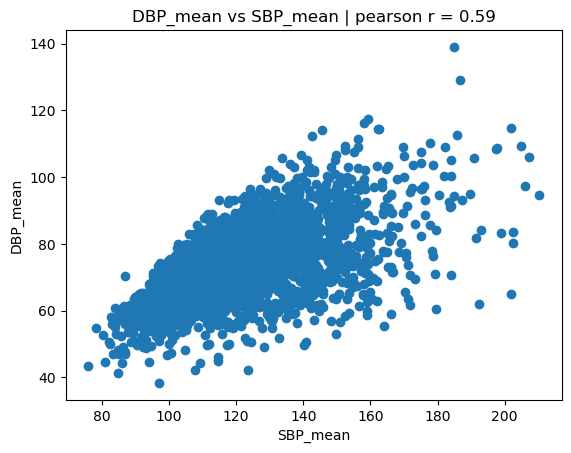

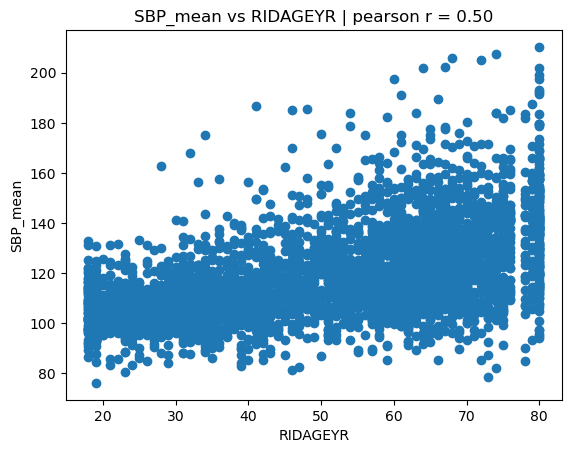

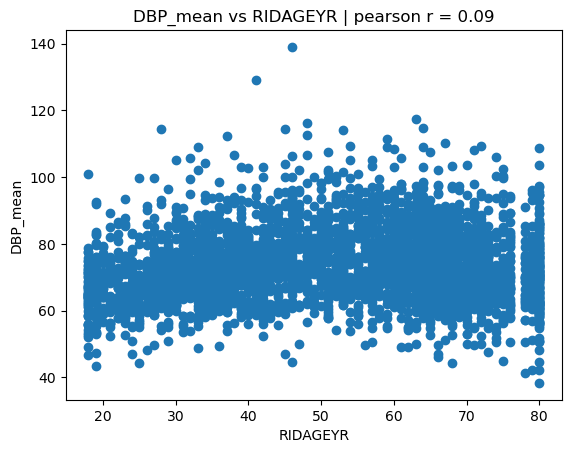

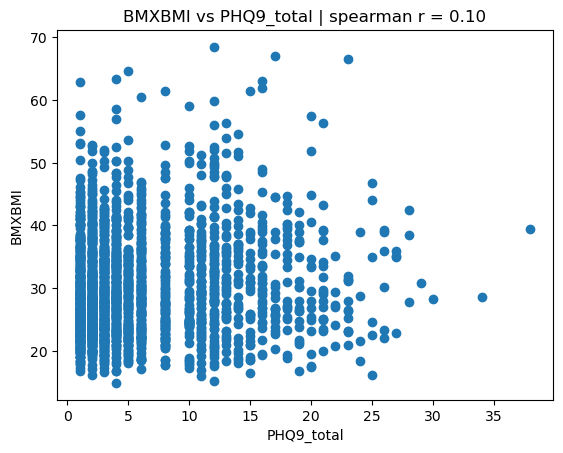

In [44]:
# Antropometría
if "BMXBMI" in num_cols and "BMXWAIST" in num_cols:
    scatter_with_corr(df, "BMXBMI", "BMXWAIST", method="pearson")

# Presión arterial
if "SBP_mean" in num_cols and "DBP_mean" in num_cols:
    scatter_with_corr(df, "SBP_mean", "DBP_mean", method="pearson")

# Edad vs presión
if "RIDAGEYR" in num_cols and "SBP_mean" in num_cols:
    scatter_with_corr(df, "RIDAGEYR", "SBP_mean", method="pearson")

if "RIDAGEYR" in num_cols and "DBP_mean" in num_cols:
    scatter_with_corr(df, "RIDAGEYR", "DBP_mean", method="pearson")

# Salud mental vs antropometría (si está PHQ9)
if "PHQ9_total" in num_cols and "BMXBMI" in num_cols:
    scatter_with_corr(df, "PHQ9_total", "BMXBMI", method="spearman")

### BOXPLOT POR CATEGORÍA 

In [45]:
def boxplot_by_category(df, num_var, cat_var):
    sub = df[[num_var, cat_var]].dropna()
    if sub.empty:
        print(f"No hay datos suficientes para {num_var} por {cat_var}")
        return

    # Orden de categorías si es category
    if pd.api.types.is_categorical_dtype(sub[cat_var]):
        cats = sub[cat_var].cat.categories
    else:
        cats = sorted(sub[cat_var].unique())

    data = [sub.loc[sub[cat_var] == c, num_var].values for c in cats]

    plt.figure(figsize=(10, 4))
    plt.boxplot(data, labels=[str(c) for c in cats], showfliers=False)
    plt.title(f"{num_var} by {cat_var}")
    plt.ylabel(num_var)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [46]:
print("BMXBMI en num_cols?", "BMXBMI" in num_cols)
print("SBP_mean en num_cols?", "SBP_mean" in num_cols)
print("PHQ9_total en num_cols?", "PHQ9_total" in num_cols)

print("SMQ020_label en cat_cols?", "SMQ020_label" in cat_cols)
print("DMDEDUC2_label en cat_cols?", "DMDEDUC2_label" in cat_cols)
print("ALQ111_label en cat_cols?", "ALQ111_label" in cat_cols)

# Extra: confirmar que existen en df
print("SMQ020_label en df.columns?", "SMQ020_label" in df.columns)
print("DMDEDUC2_label en df.columns?", "DMDEDUC2_label" in df.columns)
print("ALQ111_label en df.columns?", "ALQ111_label" in df.columns)

BMXBMI en num_cols? True
SBP_mean en num_cols? True
PHQ9_total en num_cols? True
SMQ020_label en cat_cols? True
DMDEDUC2_label en cat_cols? True
ALQ111_label en cat_cols? True
SMQ020_label en df.columns? True
DMDEDUC2_label en df.columns? True
ALQ111_label en df.columns? True


C:\Users\carme\AppData\Local\Temp\ipykernel_4324\3685188365.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(sub[cat_var]):
C:\Users\carme\AppData\Local\Temp\ipykernel_4324\3685188365.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in cats], showfliers=False)


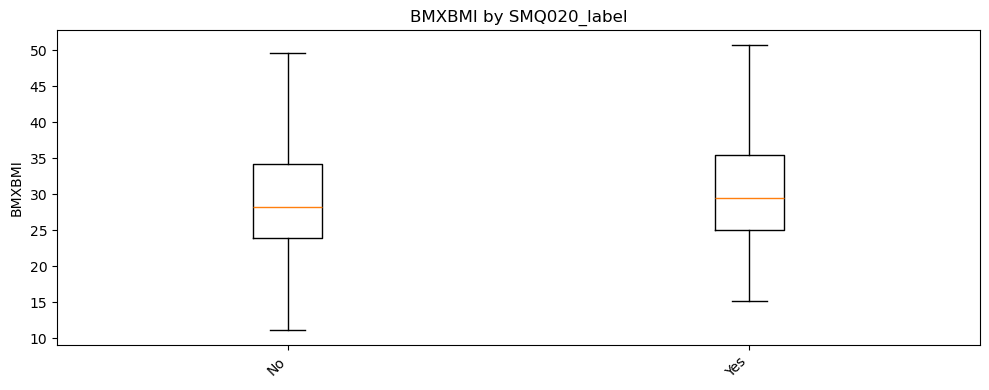

C:\Users\carme\AppData\Local\Temp\ipykernel_4324\3685188365.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(sub[cat_var]):
C:\Users\carme\AppData\Local\Temp\ipykernel_4324\3685188365.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in cats], showfliers=False)


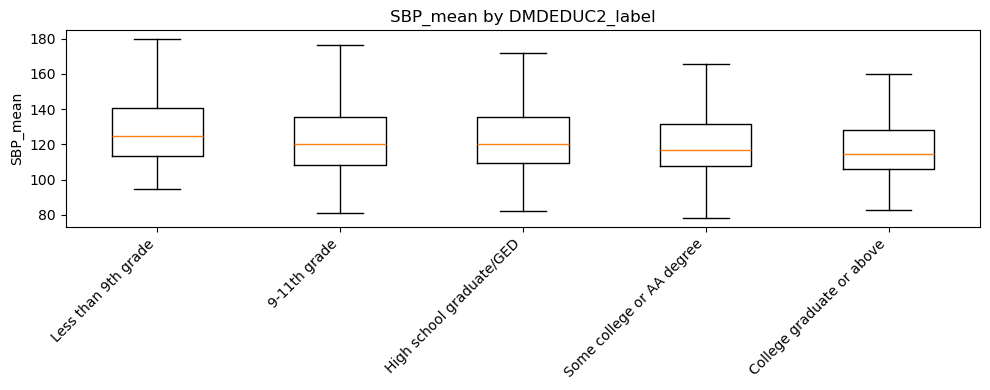

C:\Users\carme\AppData\Local\Temp\ipykernel_4324\3685188365.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(sub[cat_var]):
C:\Users\carme\AppData\Local\Temp\ipykernel_4324\3685188365.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(c) for c in cats], showfliers=False)


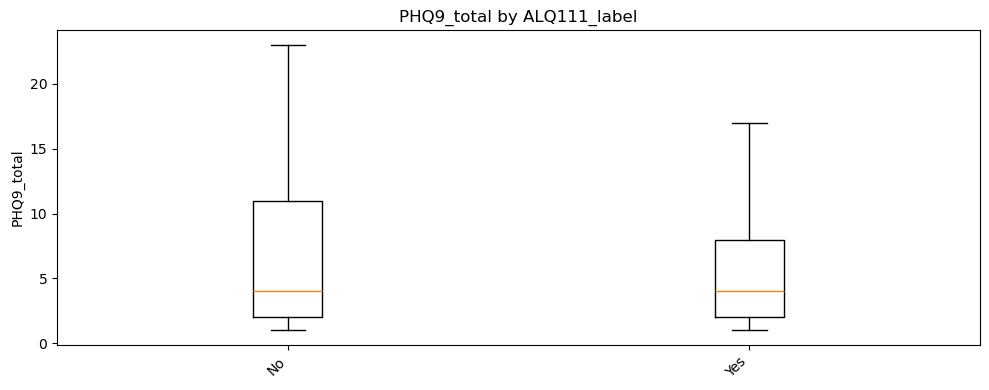

In [47]:
# BMI por tabaquismo
if "BMXBMI" in num_cols and "SMQ020_label" in cat_cols:
    boxplot_by_category(df, "BMXBMI", "SMQ020_label")

# SBP por educación
if "SBP_mean" in num_cols and "DMDEDUC2_label" in cat_cols:
    boxplot_by_category(df, "SBP_mean", "DMDEDUC2_label")

# PHQ9 por alcohol (si PHQ9 existe)
if "PHQ9_total" in num_cols and "ALQ111_label" in cat_cols:
    boxplot_by_category(df, "PHQ9_total", "ALQ111_label")

### MATRIZ DE CORRELACIÓN CON WINSORIZACIÓN PARA COMPROBAR ESTABILIDAD 

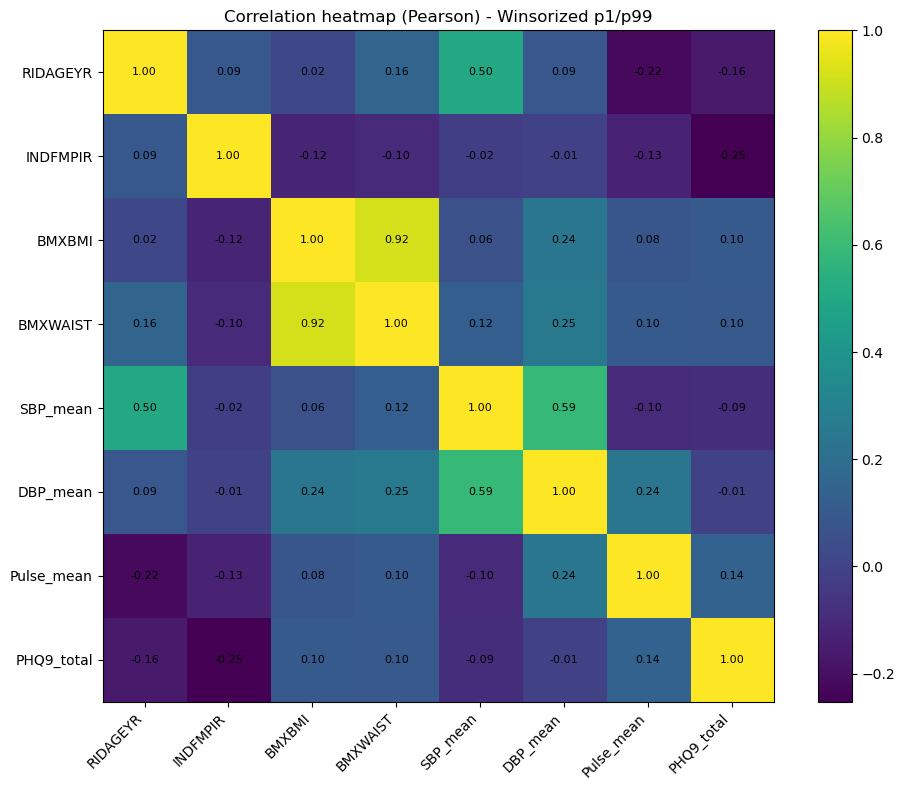

In [48]:
def winsorize_df(df_in: pd.DataFrame, cols: list, p_low=0.01, p_high=0.99):
    df_out = df_in.copy()
    for c in cols:
        s = pd.to_numeric(df_out[c], errors="coerce")
        lo = s.quantile(p_low)
        hi = s.quantile(p_high)
        df_out[c] = s.clip(lower=lo, upper=hi)
    return df_out

df_wins_num = winsorize_df(df[num_cols], num_cols, p_low=0.01, p_high=0.99)
corr_wins = df_wins_num.corr(method="pearson")

plot_corr_heatmap(corr_wins, "Correlation heatmap (Pearson) - Winsorized p1/p99")

### COMPARACIÓN DE OPCIONES

In [49]:
import numpy as np
import pandas as pd

# Defino lo que va a entrar en el PCA 
core_num = [
    "RIDAGEYR",   # edad
    "INDFMPIR",   # ingresos
    "BMXBMI",     # BMI
    "BMXWAIST",   # cintura
    "SBP_mean",   # sistólica
    "DBP_mean",   # diastólica
    "Pulse_mean", # pulso
]

with_phq = core_num + ["PHQ9_total"]

df_pca_main = df[core_num].dropna().copy()

df_pca_phq = df[with_phq].dropna().copy()

df_imp = df[core_num].copy()
if "INDFMPIR" in df_imp.columns:
    df_imp["INDFMPIR"] = df_imp["INDFMPIR"].fillna(df_imp["INDFMPIR"].median())
df_pca_main_imp_income = df_imp.dropna().copy()

print("N original df_eda_all:", df.shape[0])
print("N PCA principal (core, sin PHQ9):", df_pca_main.shape[0])
print("N PCA secundario (core + PHQ9):", df_pca_phq.shape[0])
print("N PCA principal + imputación INDFMPIR:", df_pca_main_imp_income.shape[0])


N original df_eda_all: 4496
N PCA principal (core, sin PHQ9): 2695
N PCA secundario (core + PHQ9): 1771
N PCA principal + imputación INDFMPIR: 3077


In [50]:
print(df_pca_main_imp_income.shape)

(3077, 7)


## ESCALADO PREVIO A TÉCNICAS MULTIVARIANTES

In [51]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler

df = df_eda_all.copy()

# Variables numéricas core (PCA principal)
core_vars = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "SBP_mean",
    "DBP_mean",
    "Pulse_mean"
]

### TRATAMIENTO DE VARIABLES ORDINALES Y BINARIAS

In [54]:
# Binarias: Yes/No -> 1/0 (manteniendo NA)
bin_map = {"Yes": 1, "No": 0}

if "SMQ020_label" in df.columns:
    df["SMQ020_bin"] = df["SMQ020_label"].astype("object").map(bin_map)

if "ALQ111_label" in df.columns:
    df["ALQ111_bin"] = df["ALQ111_label"].astype("object").map(bin_map)

print("Binarias creadas (si existían):",
      [c for c in ["SMQ020_bin", "ALQ111_bin"] if c in df.columns])

Binarias creadas (si existían): ['SMQ020_bin', 'ALQ111_bin']


### ORDINAL (EDUCACIÓN): CONVERTIR A "SCORE" ORDINAL 1-5

In [55]:
if "DMDEDUC2_label" in df.columns:
    # Convierte ordinal categórica en códigos 1..K (manteniendo NA)
    df["DMDEDUC2_ord"] = df["DMDEDUC2_label"].cat.codes.replace(-1, np.nan) + 1

print("Ordinal creada (si existía):",
      "DMDEDUC2_ord" in df.columns)

Ordinal creada (si existía): True


### WINSORIZACIÓN + MISSING

In [56]:
def winsorize_df(df_in, cols, p_low=0.01, p_high=0.99):
    df_out = df_in.copy()
    for c in cols:
        low = df_out[c].quantile(p_low)
        high = df_out[c].quantile(p_high)
        df_out[c] = df_out[c].clip(lower=low, upper=high)
    return df_out

X = df[core_vars].copy()

X = winsorize_df(X, core_vars, p_low=0.01, p_high=0.99)

X["INDFMPIR"] = X["INDFMPIR"].fillna(X["INDFMPIR"].median())

X = X.dropna()

print("Tamaño final de X (sin NA):", X.shape)

Tamaño final de X (sin NA): (3077, 7)


1. StandardScaler

In [57]:
scaler_std = StandardScaler()
X_std = pd.DataFrame(
    scaler_std.fit_transform(X),
    columns=core_vars,
    index=X.index
)

print("X_std listo para PCA:", X_std.shape)

X_std listo para PCA: (3077, 7)


2. RobustScaler

In [58]:
scaler_rob = RobustScaler()
X_rob = pd.DataFrame(
    scaler_rob.fit_transform(X),
    columns=core_vars,
    index=X.index
)

print("X_rob listo para PCA (comparación):", X_rob.shape)

X_rob listo para PCA (comparación): (3077, 7)


# PCA

## PASO 1. Carga del dataset EDA y validación mínima

In [60]:
print("Shape del dataset EDA:", df_eda_all.shape)
display(df_eda_all.head())

Shape del dataset EDA: (4496, 14)


,RIDAGEYR,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,SBP_mean,DBP_mean,Pulse_mean,SMQ020,ALQ111,PHQ9_total,DMDEDUC2_label,SMQ020_label,ALQ111_label
2,44.0,3.0,1.41,29.7,93.5,109.000000,78.333333,81.333333,2.0,1.0,2.0,High school graduate/GED,No,Yes
7,65.0,3.0,5.00,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,High school graduate/GED,No,NaN
9,68.0,5.0,1.32,42.6,122.0,141.333333,76.000000,79.000000,2.0,1.0,NaN,College graduate or above,No,Yes
10,27.0,4.0,0.81,43.7,118.5,129.000000,99.666667,82.000000,1.0,NaN,NaN,Some college or AA degree,Yes,NaN
12,31.0,3.0,2.16,46.0,131.0,111.333333,74.666667,94.333333,2.0,NaN,NaN,High school graduate/GED,No,NaN


In [61]:
expected_cols = [
    "RIDAGEYR",
    "DMDEDUC2",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "SBP_mean",
    "DBP_mean",
    "Pulse_mean",
    "SMQ020",
    "ALQ111",
    "PHQ9_total"
]

missing_cols = [col for col in expected_cols if col not in df_eda_all.columns]
extra_cols = [col for col in df_eda_all.columns if col not in expected_cols]

print("Columnas esperadas:", expected_cols)
print("Faltan columnas:", missing_cols)
print("Columnas extra en el dataset:", extra_cols)

assert len(missing_cols) == 0, f"Faltan columnas necesarias: {missing_cols}"

Columnas esperadas: ['RIDAGEYR', 'DMDEDUC2', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'SBP_mean', 'DBP_mean', 'Pulse_mean', 'SMQ020', 'ALQ111', 'PHQ9_total']
Faltan columnas: []
Columnas extra en el dataset: ['DMDEDUC2_label', 'SMQ020_label', 'ALQ111_label']


In [62]:
missing_summary = (
    df_eda_all[expected_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("prop_missing")
    .to_frame()
)

missing_summary["pct_missing"] = (missing_summary["prop_missing"] * 100).round(2)
display(missing_summary)

,prop_missing,pct_missing
PHQ9_total,0.513345,51.33
ALQ111,0.338968,33.90
BMXWAIST,0.274466,27.45
DBP_mean,0.264457,26.45
Pulse_mean,0.264012,26.40
SBP_mean,0.258674,25.87
BMXBMI,0.239769,23.98
INDFMPIR,0.168372,16.84
DMDEDUC2,0.041593,4.16
RIDAGEYR,0.010899,1.09


## Paso 2. Definición de grupos de variables

In [ ]:
# Variables numéricas centrales para PCA principal
core_num = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "SBP_mean",
    "DBP_mean",
    "Pulse_mean"
]

# Variables auxiliares de interpretación (no entran en el PCA principal)
ordinal_vars = ["DMDEDUC2"]
binary_vars = ["SMQ020", "ALQ111"]
secondary_num = ["PHQ9_total"]

# PCA principal
pca_main_vars = core_num

# PCA secundario opcional para sensibilidad
pca_phq_vars = core_num + ["PHQ9_total"]

print("Variables PCA principal:", pca_main_vars)
print("Variables auxiliares:", ordinal_vars + binary_vars + secondary_num)

Variables PCA principal: ['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'SBP_mean', 'DBP_mean', 'Pulse_mean']
Variables auxiliares: ['DMDEDUC2', 'SMQ020', 'ALQ111', 'PHQ9_total']


## Paso 3. Construcción del dataset analítico para PCA principal

In [68]:
df_pca_main = df_eda_all[pca_main_vars].copy()

print("Shape inicial df_pca_main:", df_pca_main.shape)
print("\nMissing inicial:")
display(df_pca_main.isna().mean().sort_values(ascending=False).to_frame("prop_missing"))

Shape inicial df_pca_main: (4496, 7)

Missing inicial:


,prop_missing
BMXWAIST,0.274466
DBP_mean,0.264457
Pulse_mean,0.264012
SBP_mean,0.258674
BMXBMI,0.239769
INDFMPIR,0.168372
RIDAGEYR,0.010899


In [70]:
if "INDFMPIR" in df_pca_main.columns:
    mediana_ingresos = df_pca_main["INDFMPIR"].median()
    df_pca_main["INDFMPIR"] = df_pca_main["INDFMPIR"].fillna(mediana_ingresos)
    print(f"INDFMPIR imputada con mediana = {mediana_ingresos:.3f}")

n_before = df_pca_main.shape[0]
df_pca_main = df_pca_main.dropna().copy()
n_after = df_pca_main.shape[0]

print(f"Filas antes del dropna final: {n_before}")
print(f"Filas después del dropna final: {n_after}")
print(f"Filas eliminadas: {n_before - n_after}")

INDFMPIR imputada con mediana = 2.570
Filas antes del dropna final: 3077
Filas después del dropna final: 3077
Filas eliminadas: 0


## Paso 4. Reutilizar tu decisión de winsorización p1/p99

In [71]:
def winsorize_series(s, p_low=0.01, p_high=0.99):
    low = s.quantile(p_low)
    high = s.quantile(p_high)
    return s.clip(lower=low, upper=high)

def winsorize_df(df, cols, p_low=0.01, p_high=0.99):
    df_out = df.copy()
    bounds = {}

    for col in cols:
        low = df_out[col].quantile(p_low)
        high = df_out[col].quantile(p_high)
        df_out[col] = df_out[col].clip(lower=low, upper=high)
        bounds[col] = {"p1": low, "p99": high}

    bounds_df = pd.DataFrame(bounds).T
    return df_out, bounds_df

In [72]:
df_pca_main_wins, wins_bounds = winsorize_df(df_pca_main, pca_main_vars)

print("Bounds usados en winsorización:")
display(wins_bounds.round(3))

Bounds usados en winsorización:


,p1,p99
RIDAGEYR,18.000,80.000
INDFMPIR,0.020,5.000
BMXBMI,17.700,52.500
BMXWAIST,67.452,142.272
SBP_mean,87.667,178.413
DBP_mean,50.667,103.667
Pulse_mean,49.253,104.000


In [73]:
print("Shape antes de winsorizar:", df_pca_main.shape)
print("Shape después de winsorizar:", df_pca_main_wins.shape)

Shape antes de winsorizar: (3077, 7)
Shape después de winsorizar: (3077, 7)


## Paso 5. Escalado con StandardScaler

In [74]:
scaler_main = StandardScaler()

X_main = scaler_main.fit_transform(df_pca_main_wins[pca_main_vars])

X_main = pd.DataFrame(
    X_main,
    index=df_pca_main_wins.index,
    columns=pca_main_vars
)

print("Matriz estandarizada:")
display(X_main.head())

print("Medias aproximadas:")
display(X_main.mean().round(4))

print("Desviaciones típicas aproximadas:")
display(X_main.std(ddof=0).round(4))

Matriz estandarizada:


,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,SBP_mean,DBP_mean,Pulse_mean
2,-0.446509,-0.892119,-0.014443,-0.276960,-0.611700,0.418936,0.741353
9,0.894435,-0.949857,1.720195,1.421035,1.176345,0.197330,0.536986
10,-1.396344,-1.277035,1.868110,1.212509,0.494307,2.445051,0.799744
12,-1.172854,-0.410975,2.177386,1.957243,-0.482666,0.070698,1.879970
13,-1.061108,-1.200052,1.222663,1.528276,-0.777602,-0.119250,2.055142


Medias aproximadas:


RIDAGEYR     -0.0
INDFMPIR     -0.0
BMXBMI        0.0
BMXWAIST      0.0
SBP_mean     -0.0
DBP_mean     -0.0
Pulse_mean   -0.0
dtype: float64

Desviaciones típicas aproximadas:


RIDAGEYR      1.0
INDFMPIR      1.0
BMXBMI        1.0
BMXWAIST      1.0
SBP_mean      1.0
DBP_mean      1.0
Pulse_mean    1.0
dtype: float64

## Paso 6. Ajuste inicial del PCA completo

In [75]:
pca_full = PCA()
scores_full = pca_full.fit_transform(X_main)

explained_var_ratio = pca_full.explained_variance_ratio_
explained_var = pca_full.explained_variance_
cum_explained = explained_var_ratio.cumsum()

tabla_varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(explained_var_ratio))],
    "Autovalor": explained_var,
    "Varianza_explicada": explained_var_ratio,
    "Varianza_acumulada": cum_explained
})

display(tabla_varianza.round(4))

,Componente,Autovalor,Varianza_explicada,Varianza_acumulada
0,PC1,2.2412,0.3201,0.3201
1,PC2,1.6468,0.2352,0.5552
2,PC3,1.2258,0.1751,0.7303
3,PC4,0.9408,0.1344,0.8647
4,PC5,0.6540,0.0934,0.9581
5,PC6,0.2246,0.0321,0.9901
6,PC7,0.0691,0.0099,1.0000


## Paso 7. Scree plot

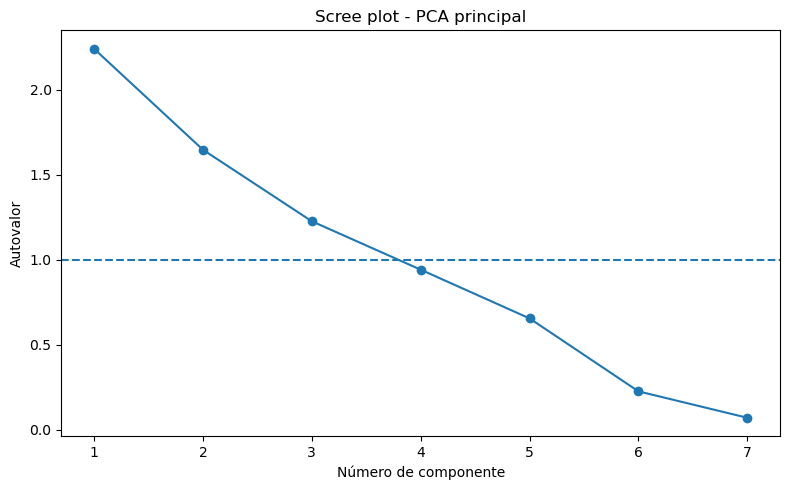

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_var) + 1),
    explained_var,
    marker="o"
)
plt.xticks(range(1, len(explained_var) + 1))
plt.xlabel("Número de componente")
plt.ylabel("Autovalor")
plt.title("Scree plot - PCA principal")
plt.axhline(y=1, linestyle="--")
plt.tight_layout()
plt.show()

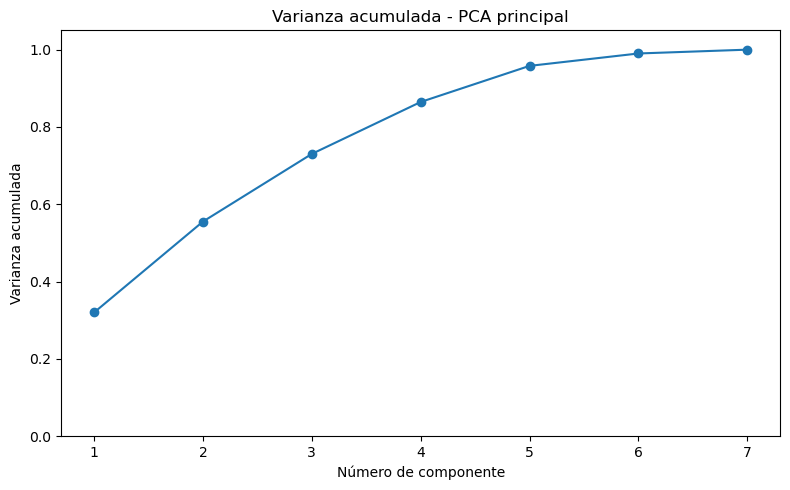

In [77]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cum_explained) + 1),
    cum_explained,
    marker="o"
)
plt.xticks(range(1, len(cum_explained) + 1))
plt.xlabel("Número de componente")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada - PCA principal")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Paso 8. Ajuste del PCA final con número de componentes elegido

In [78]:
n_components = 3

pca_main = PCA(n_components=n_components)
scores_main = pca_main.fit_transform(X_main)

scores_main = pd.DataFrame(
    scores_main,
    index=X_main.index,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

display(scores_main.head())

,PC1,PC2,PC3
2,-0.152909,-0.839884,0.991618
9,2.585484,-0.275343,-0.235887
10,2.796431,-1.537332,1.670632
12,2.085198,-2.938343,0.357209
13,1.257364,-2.839190,0.883898


## Paso 9. Cargas factoriales y contribución de variables

In [79]:
loadings = pd.DataFrame(
    pca_main.components_.T,
    index=pca_main_vars,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

display(loadings.round(4))

,PC1,PC2,PC3
RIDAGEYR,0.2323,0.5207,-0.2909
INDFMPIR,-0.0861,0.2250,-0.2648
BMXBMI,0.5315,-0.3698,-0.2843
BMXWAIST,0.5646,-0.2920,-0.2946
SBP_mean,0.3692,0.5573,0.2112
DBP_mean,0.4346,0.2059,0.4960
Pulse_mean,0.1104,-0.3213,0.6222


In [80]:
loadings_abs = loadings.abs().sort_values(by="PC1", ascending=False)
display(loadings_abs.round(4))

,PC1,PC2,PC3
BMXWAIST,0.5646,0.2920,0.2946
BMXBMI,0.5315,0.3698,0.2843
DBP_mean,0.4346,0.2059,0.4960
SBP_mean,0.3692,0.5573,0.2112
RIDAGEYR,0.2323,0.5207,0.2909
Pulse_mean,0.1104,0.3213,0.6222
INDFMPIR,0.0861,0.2250,0.2648


## Paso 10. Biplot sencillo de PC1 y PC2

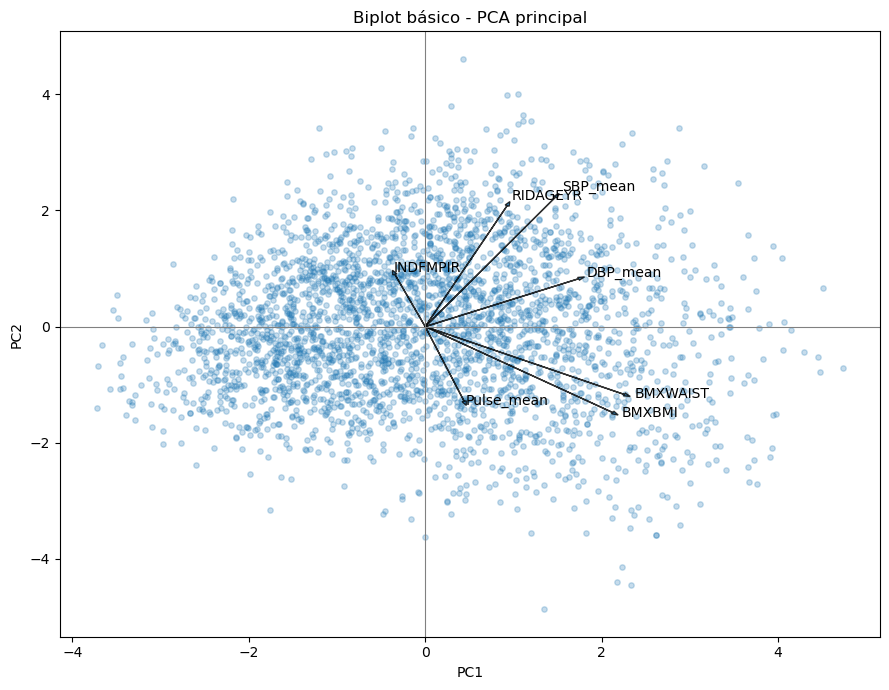

In [81]:
plt.figure(figsize=(9, 7))

# puntos de individuos
plt.scatter(
    scores_main["PC1"],
    scores_main["PC2"],
    alpha=0.25,
    s=15
)

# flechas de variables
for var in pca_main_vars:
    plt.arrow(
        0, 0,
        loadings.loc[var, "PC1"] * 4,
        loadings.loc[var, "PC2"] * 4,
        head_width=0.05,
        alpha=0.8
    )
    plt.text(
        loadings.loc[var, "PC1"] * 4.2,
        loadings.loc[var, "PC2"] * 4.2,
        var,
        fontsize=10
    )

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot básico - PCA principal")
plt.tight_layout()
plt.show()

## Paso 11. Fijar formalmente el PCA final con 3 componentes

In [82]:
n_components = 3

pca_main = PCA(n_components=n_components)
scores_main_array = pca_main.fit_transform(X_main)

scores_main = pd.DataFrame(
    scores_main_array,
    index=X_main.index,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

print("Shape de scores_main:", scores_main.shape)
display(scores_main.head())

Shape de scores_main: (3077, 3)


,PC1,PC2,PC3
2,-0.152909,-0.839884,0.991618
9,2.585484,-0.275343,-0.235887
10,2.796431,-1.537332,1.670632
12,2.085198,-2.938343,0.357209
13,1.257364,-2.839190,0.883898


## Paso 12. Tabla final de varianza explicada del PCA retenido

In [83]:
import os

PATH_OUT = "outputs_pca"
os.makedirs(PATH_OUT, exist_ok=True)

print("Carpeta de salida creada en:", PATH_OUT)

import os

tabla_varianza_final = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(n_components)],
    "Autovalor": pca_main.explained_variance_,
    "Varianza_explicada": pca_main.explained_variance_ratio_,
    "Varianza_acumulada": pca_main.explained_variance_ratio_.cumsum()
})

display(tabla_varianza_final.round(4))

tabla_varianza_final.to_csv(
    os.path.join(PATH_OUT, "tabla_varianza_pca_final_3_componentes.csv"),
    index=False
)

Carpeta de salida creada en: outputs_pca


,Componente,Autovalor,Varianza_explicada,Varianza_acumulada
0,PC1,2.2412,0.3201,0.3201
1,PC2,1.6468,0.2352,0.5552
2,PC3,1.2258,0.1751,0.7303


## Paso 13. Loadings del PCA final

In [84]:
loadings = pd.DataFrame(
    pca_main.components_.T,
    index=pca_main_vars,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

display(loadings.round(4))

loadings.to_csv(
    os.path.join(PATH_OUT, "loadings_pca_final.csv")
)

,PC1,PC2,PC3
RIDAGEYR,0.2323,0.5207,-0.2909
INDFMPIR,-0.0861,0.2250,-0.2648
BMXBMI,0.5315,-0.3698,-0.2843
BMXWAIST,0.5646,-0.2920,-0.2946
SBP_mean,0.3692,0.5573,0.2112
DBP_mean,0.4346,0.2059,0.4960
Pulse_mean,0.1104,-0.3213,0.6222


In [85]:
loadings_abs = loadings.abs()

for pc in loadings_abs.columns:
    print(f"\nVariables más influyentes en {pc}:")
    display(loadings_abs[[pc]].sort_values(by=pc, ascending=False).round(4))


Variables más influyentes en PC1:


,PC1
BMXWAIST,0.5646
BMXBMI,0.5315
DBP_mean,0.4346
SBP_mean,0.3692
RIDAGEYR,0.2323
Pulse_mean,0.1104
INDFMPIR,0.0861



Variables más influyentes en PC2:


,PC2
SBP_mean,0.5573
RIDAGEYR,0.5207
BMXBMI,0.3698
Pulse_mean,0.3213
BMXWAIST,0.2920
INDFMPIR,0.2250
DBP_mean,0.2059



Variables más influyentes en PC3:


,PC3
Pulse_mean,0.6222
DBP_mean,0.4960
BMXWAIST,0.2946
RIDAGEYR,0.2909
BMXBMI,0.2843
INDFMPIR,0.2648
SBP_mean,0.2112


## Paso 14. Cálculo de cos²

In [87]:
cos2 = loadings ** 2

display(cos2.round(4))

cos2.to_csv(
    os.path.join(PATH_OUT, "cos2_variables_pca.csv")
)

,PC1,PC2,PC3
RIDAGEYR,0.0540,0.2712,0.0846
INDFMPIR,0.0074,0.0506,0.0701
BMXBMI,0.2825,0.1367,0.0808
BMXWAIST,0.3187,0.0853,0.0868
SBP_mean,0.1363,0.3106,0.0446
DBP_mean,0.1889,0.0424,0.2460
Pulse_mean,0.0122,0.1032,0.3871


In [88]:
cos2_total = cos2.sum(axis=1).to_frame(name="Cos2_total_PC1_PC3")
display(cos2_total.sort_values(by="Cos2_total_PC1_PC3", ascending=False).round(4))

cos2_total.to_csv(
    os.path.join(PATH_OUT, "cos2_total_variables_pca.csv")
)

,Cos2_total_PC1_PC3
Pulse_mean,0.5025
BMXBMI,0.5001
SBP_mean,0.4915
BMXWAIST,0.4908
DBP_mean,0.4773
RIDAGEYR,0.4097
INDFMPIR,0.1282


## Paso 15. Contribuciones de las variables a cada componente

In [89]:
contrib = cos2.div(cos2.sum(axis=0), axis=1) * 100

display(contrib.round(2))

contrib.to_csv(
    os.path.join(PATH_OUT, "contribuciones_variables_pca.csv")
)

,PC1,PC2,PC3
RIDAGEYR,5.40,27.12,8.46
INDFMPIR,0.74,5.06,7.01
BMXBMI,28.25,13.67,8.08
BMXWAIST,31.87,8.53,8.68
SBP_mean,13.63,31.06,4.46
DBP_mean,18.89,4.24,24.60
Pulse_mean,1.22,10.32,38.71


In [90]:
for pc in contrib.columns:
    print(f"\nContribuciones en {pc}:")
    display(contrib[[pc]].sort_values(by=pc, ascending=False).round(2))


Contribuciones en PC1:


,PC1
BMXWAIST,31.87
BMXBMI,28.25
DBP_mean,18.89
SBP_mean,13.63
RIDAGEYR,5.40
Pulse_mean,1.22
INDFMPIR,0.74



Contribuciones en PC2:


,PC2
SBP_mean,31.06
RIDAGEYR,27.12
BMXBMI,13.67
Pulse_mean,10.32
BMXWAIST,8.53
INDFMPIR,5.06
DBP_mean,4.24



Contribuciones en PC3:


,PC3
Pulse_mean,38.71
DBP_mean,24.60
BMXWAIST,8.68
RIDAGEYR,8.46
BMXBMI,8.08
INDFMPIR,7.01
SBP_mean,4.46


## Paso 16. Tabla resumen unificada para interpretación

In [91]:
resumen_pca = {}

for pc in loadings.columns:
    resumen_pc = pd.DataFrame({
        "loading": loadings[pc],
        "abs_loading": loadings[pc].abs(),
        "cos2": cos2[pc],
        "contrib_pct": contrib[pc]
    }).sort_values(by="abs_loading", ascending=False)
    
    resumen_pca[pc] = resumen_pc
    print(f"\nResumen para {pc}:")
    display(resumen_pc.round(4))
    
    resumen_pc.to_csv(
        os.path.join(PATH_OUT, f"resumen_interpretacion_{pc}.csv")
    )


Resumen para PC1:


,loading,abs_loading,cos2,contrib_pct
BMXWAIST,0.5646,0.5646,0.3187,31.8734
BMXBMI,0.5315,0.5315,0.2825,28.2503
DBP_mean,0.4346,0.4346,0.1889,18.8886
SBP_mean,0.3692,0.3692,0.1363,13.6313
RIDAGEYR,0.2323,0.2323,0.0540,5.3971
Pulse_mean,0.1104,0.1104,0.0122,1.2178
INDFMPIR,-0.0861,0.0861,0.0074,0.7415



Resumen para PC2:


,loading,abs_loading,cos2,contrib_pct
SBP_mean,0.5573,0.5573,0.3106,31.0563
RIDAGEYR,0.5207,0.5207,0.2712,27.1165
BMXBMI,-0.3698,0.3698,0.1367,13.6736
Pulse_mean,-0.3213,0.3213,0.1032,10.3242
BMXWAIST,-0.2920,0.2920,0.0853,8.5255
INDFMPIR,0.2250,0.2250,0.0506,5.0637
DBP_mean,0.2059,0.2059,0.0424,4.2402



Resumen para PC3:


,loading,abs_loading,cos2,contrib_pct
Pulse_mean,0.6222,0.6222,0.3871,38.7123
DBP_mean,0.4960,0.4960,0.2460,24.5973
BMXWAIST,-0.2946,0.2946,0.0868,8.6783
RIDAGEYR,-0.2909,0.2909,0.0846,8.4601
BMXBMI,-0.2843,0.2843,0.0808,8.0815
INDFMPIR,-0.2648,0.2648,0.0701,7.0101
SBP_mean,0.2112,0.2112,0.0446,4.4605


## Paso 17. Gráfico de contribuciones por componente

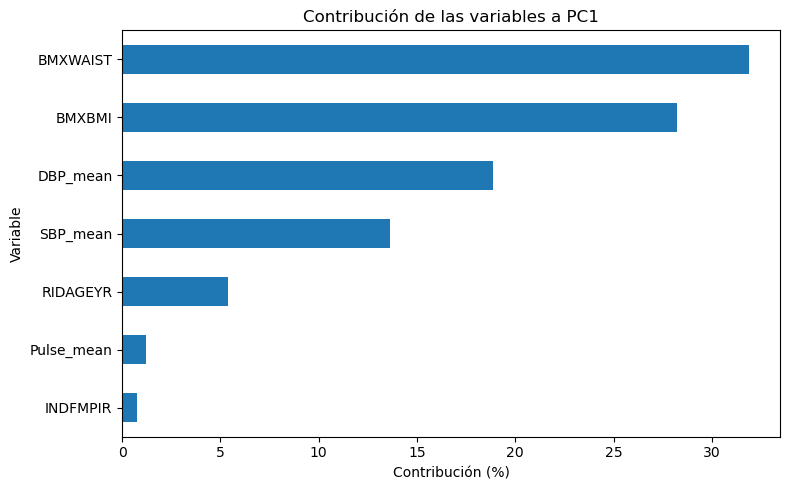

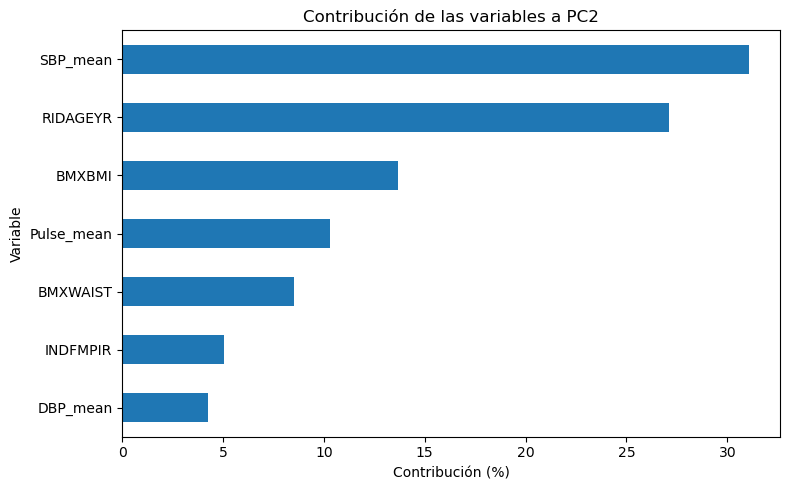

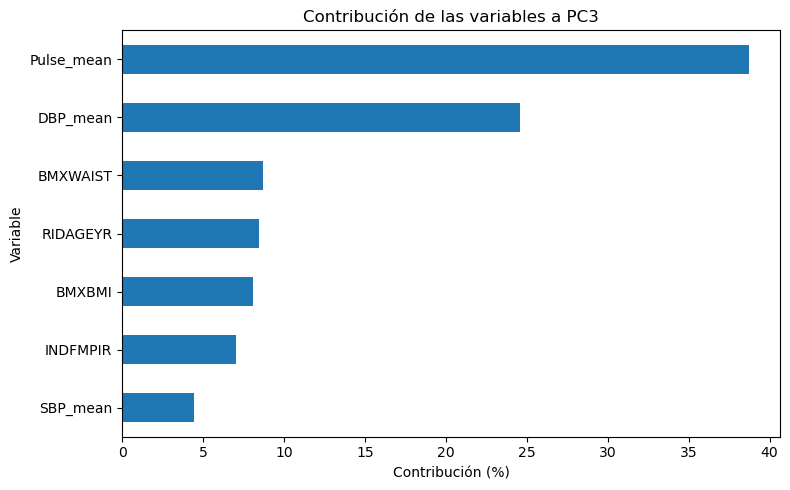

In [92]:
for pc in contrib.columns:
    plt.figure(figsize=(8, 5))
    contrib[pc].sort_values(ascending=True).plot(kind="barh")
    plt.title(f"Contribución de las variables a {pc}")
    plt.xlabel("Contribución (%)")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

## Paso 18. Círculo de correlaciones

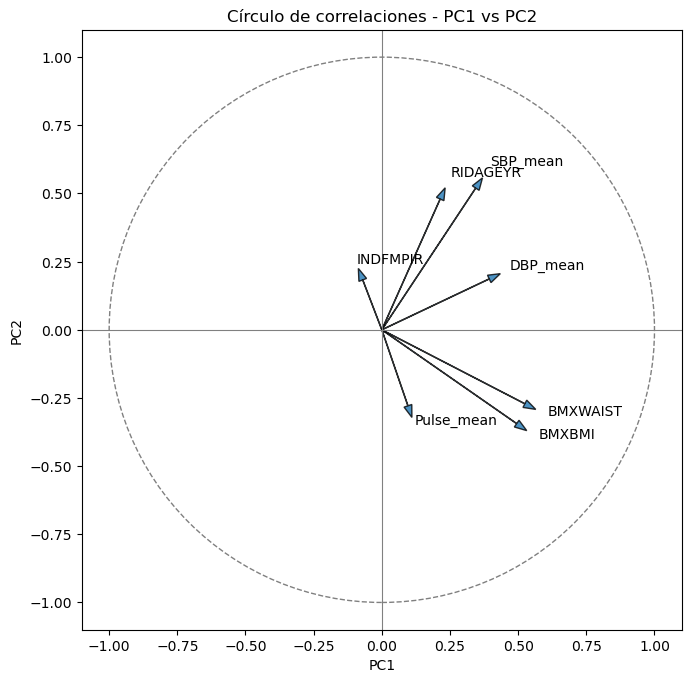

In [93]:
plt.figure(figsize=(7, 7))

circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
plt.gca().add_artist(circle)

for var in pca_main_vars:
    x = loadings.loc[var, "PC1"]
    y = loadings.loc[var, "PC2"]
    
    plt.arrow(0, 0, x, y, head_width=0.03, alpha=0.8, length_includes_head=True)
    plt.text(x * 1.08, y * 1.08, var, fontsize=10)

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Círculo de correlaciones - PC1 vs PC2")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Paso 19. Mapa de individuos en el plano principal

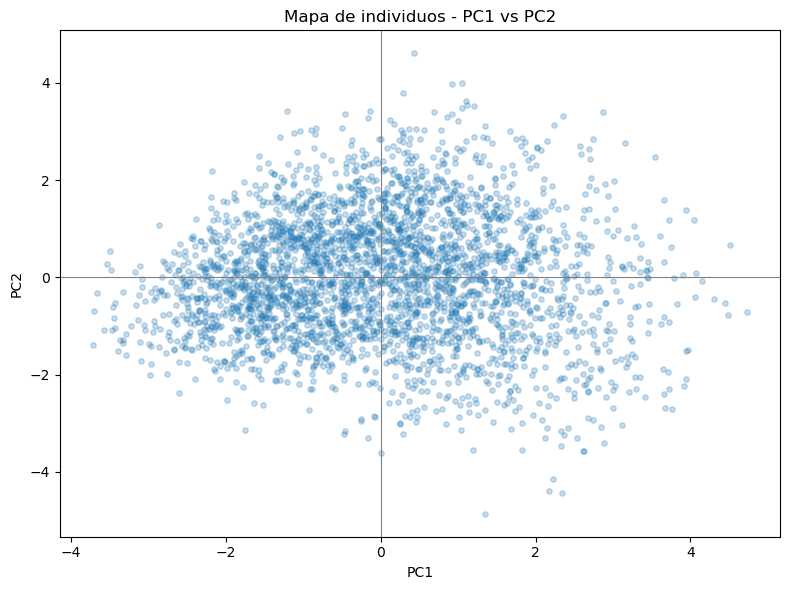

In [94]:
plt.figure(figsize=(8, 6))
plt.scatter(
    scores_main["PC1"],
    scores_main["PC2"],
    alpha=0.25,
    s=15
)

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Mapa de individuos - PC1 vs PC2")
plt.tight_layout()
plt.show()

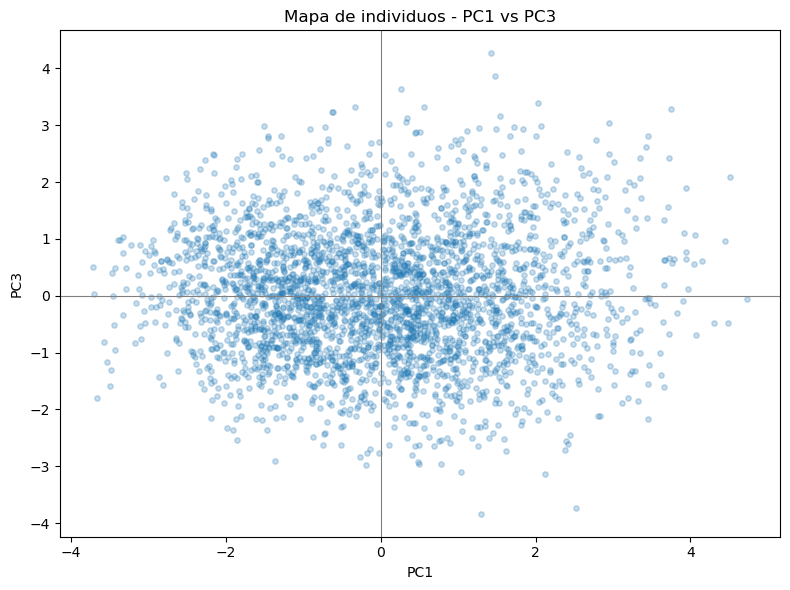

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(
    scores_main["PC1"],
    scores_main["PC3"],
    alpha=0.25,
    s=15
)

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.title("Mapa de individuos - PC1 vs PC3")
plt.tight_layout()
plt.show()

## Paso 20. Biplot final más limpio

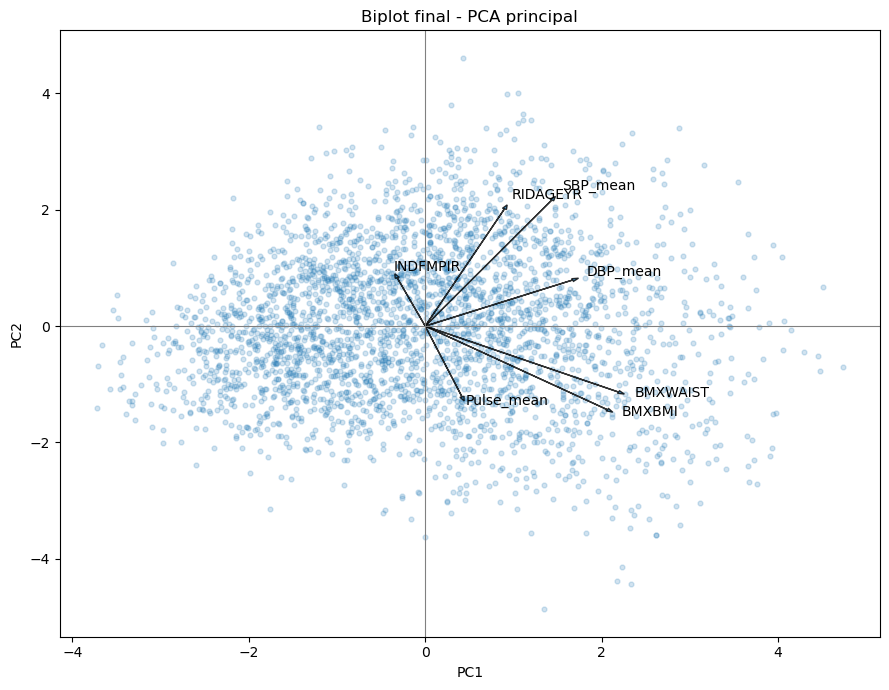

In [97]:
plt.figure(figsize=(9, 7))

plt.scatter(
    scores_main["PC1"],
    scores_main["PC2"],
    alpha=0.20,
    s=12
)

for var in pca_main_vars:
    x = loadings.loc[var, "PC1"]
    y = loadings.loc[var, "PC2"]
    plt.arrow(
        0, 0, x * 4, y * 4,
        head_width=0.05,
        alpha=0.8,
        length_includes_head=True
    )
    plt.text(x * 4.2, y * 4.2, var, fontsize=10)

plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot final - PCA principal")
plt.tight_layout()
plt.show()

## Paso 21. Dejar preparados los datos para clustering

In [98]:
df_for_clustering = scores_main.copy()

print("Shape del dataset para clustering:", df_for_clustering.shape)
display(df_for_clustering.head())

Shape del dataset para clustering: (3077, 3)


,PC1,PC2,PC3
2,-0.152909,-0.839884,0.991618
9,2.585484,-0.275343,-0.235887
10,2.796431,-1.537332,1.670632
12,2.085198,-2.938343,0.357209
13,1.257364,-2.839190,0.883898


In [99]:
df_for_clustering.to_csv(
    os.path.join(PATH_OUT, "dataset_scores_para_clustering.csv")
)

# CLUSTERING